In [3]:
# Cell 1 — Imports

from pathlib import Path
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Cell 2

GLI_ROOT = Path("/kaggle/input/datasets/ahmedelzayat77/bratsglioma/Training")
print("Dataset root:", GLI_ROOT)
print("Exists:", GLI_ROOT.exists())

Dataset root: /kaggle/input/datasets/ahmedelzayat77/bratsglioma/Training
Exists: True


In [5]:
# Cell 3 — Helper function: get NIfTI from modality folder

def get_nii_from_folder(folder_path: Path):
    """
    Given a folder path, return the ONLY .nii/.nii.gz file inside.
    Returns None if not found or multiple files.
    """
    if not folder_path.exists() or not folder_path.is_dir():
        return None

    nii_files = list(folder_path.glob("*.nii")) + list(folder_path.glob("*.nii.gz"))

    if len(nii_files) != 1:
        return None

    return nii_files[0]

In [6]:
# Cell 4 — Helper function: get segmentation file from case root

def get_seg_from_case_root(case_dir: Path):
    """
    Get segmentation file directly from the case root.
    Looks for *-seg.nii or *-seg.nii.gz
    """
    seg_files = list(case_dir.glob("*-seg.nii")) + list(case_dir.glob("*-seg.nii.gz"))
    seg_files = [f for f in seg_files if f.parent == case_dir]

    if len(seg_files) != 1:
        return None

    return seg_files[0]

In [7]:
# Cell 5 — Main scanner for BraTS dual structure

def scan_modalities_in_case_dual_structure(case_dir: Path):
    """
    Handles both possible structures:
    
    1) Modality stored as a folder containing one .nii/.nii.gz file
    2) Modality stored directly as a .nii/.nii.gz file in case root
    
    Returns:
        case_id, paths_dict
    """
    cid = case_dir.name
    paths = {"t1n": None, "t1c": None, "t2w": None, "t2f": None, "seg": None}

    try:
        items = os.listdir(case_dir)
    except Exception:
        return cid, paths

    for item in items:
        item_path = case_dir / item
        item_lower = item.lower()

        modality = None

        if "t1c" in item_lower or "t1ce" in item_lower:
            modality = "t1c"
        elif "t1n" in item_lower:
            modality = "t1n"
        elif "t2f" in item_lower or "flair" in item_lower:
            modality = "t2f"
        elif "t2w" in item_lower or ("t2" in item_lower and "flair" not in item_lower and "t2f" not in item_lower):
            modality = "t2w"

        if modality:
            if item_path.is_dir():
                nii_path = get_nii_from_folder(item_path)
                if nii_path:
                    paths[modality] = nii_path
            elif item.endswith(".nii") or item.endswith(".nii.gz"):
                paths[modality] = item_path

    seg_path = get_seg_from_case_root(case_dir)
    if seg_path:
        paths["seg"] = seg_path

    return cid, paths

In [8]:
# Cell 6 — Check if case is complete

def is_complete_case(paths_dict):
    return all(paths_dict[k] is not None for k in ["t1n", "t1c", "t2w", "t2f", "seg"])

In [9]:
# Cell 7 — Scan all BraTS cases

all_case_dirs = sorted([p for p in GLI_ROOT.iterdir() if p.is_dir()])

records = []

for case_dir in all_case_dirs:
    cid, paths = scan_modalities_in_case_dual_structure(case_dir)

    records.append({
        "case_id": cid,
        "t1n_path": str(paths["t1n"]) if paths["t1n"] else None,
        "t1c_path": str(paths["t1c"]) if paths["t1c"] else None,
        "t2w_path": str(paths["t2w"]) if paths["t2w"] else None,
        "t2f_path": str(paths["t2f"]) if paths["t2f"] else None,
        "seg_path": str(paths["seg"]) if paths["seg"] else None,
        "complete": is_complete_case(paths)
    })

df_cases = pd.DataFrame(records)
df_cases.head()

,case_id,t1n_path,t1c_path,t2w_path,t2f_path,seg_path,complete
0,BraTS-GLI-00000-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
1,BraTS-GLI-00002-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
2,BraTS-GLI-00003-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
3,BraTS-GLI-00005-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
4,BraTS-GLI-00006-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True


In [10]:
# Cell 8 — Summary of readable cases
print("Total case folders:", len(df_cases))
print("Complete readable cases:", df_cases["complete"].sum())
print("Incomplete cases:", (~df_cases["complete"]).sum())

Total case folders: 1251
Complete readable cases: 1251
Incomplete cases: 0


In [11]:
# Cell 9 — Keep only complete cases
df_complete = df_cases[df_cases["complete"]].reset_index(drop=True)
print("Usable complete cases:", len(df_complete))
df_complete.head()

Usable complete cases: 1251


,case_id,t1n_path,t1c_path,t2w_path,t2f_path,seg_path,complete
0,BraTS-GLI-00000-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
1,BraTS-GLI-00002-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
2,BraTS-GLI-00003-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
3,BraTS-GLI-00005-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True
4,BraTS-GLI-00006-000,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,/kaggle/input/datasets/ahmedelzayat77/bratsgli...,True


In [12]:
# Cell 10 — Load one sample case

sample_row = df_complete.iloc[0]

case_id = sample_row["case_id"]
print("Sample case:", case_id)

t1n = nib.load(sample_row["t1n_path"]).get_fdata().astype(np.float32)
t1c = nib.load(sample_row["t1c_path"]).get_fdata().astype(np.float32)
t2w = nib.load(sample_row["t2w_path"]).get_fdata().astype(np.float32)
t2f = nib.load(sample_row["t2f_path"]).get_fdata().astype(np.float32)
seg = nib.load(sample_row["seg_path"]).get_fdata().astype(np.uint8)

print("t1n shape:", t1n.shape)
print("t1c shape:", t1c.shape)
print("t2w shape:", t2w.shape)
print("t2f shape:", t2f.shape)
print("seg shape:", seg.shape)

Sample case: BraTS-GLI-00000-000
t1n shape: (240, 240, 155)
t1c shape: (240, 240, 155)
t2w shape: (240, 240, 155)
t2f shape: (240, 240, 155)
seg shape: (240, 240, 155)


In [13]:
# Cell 11 — Validate shape equality
print("All shapes equal:", t1n.shape == t1c.shape == t2w.shape == t2f.shape == seg.shape)

All shapes equal: True


In [14]:
# Cell 12 — Inspect unique segmentation labels
print("Unique labels in segmentation mask:", np.unique(seg))


Unique labels in segmentation mask: [0 1 2 3]


In [15]:
all_labels = set()

for i in range(min(20, len(df_complete))):
    row = df_complete.iloc[i]
    seg_case = nib.load(row["seg_path"]).get_fdata().astype(np.uint8)
    labels = np.unique(seg_case)
    all_labels.update(labels.tolist())
    print(f"{row['case_id']} -> {labels}")

print("\nAll labels found across checked cases:", sorted(all_labels))

BraTS-GLI-00000-000 -> [0 1 2 3]
BraTS-GLI-00002-000 -> [0 1 2 3]
BraTS-GLI-00003-000 -> [0 1 2 3]
BraTS-GLI-00005-000 -> [0 1 2 3]
BraTS-GLI-00006-000 -> [0 1 2 3]
BraTS-GLI-00008-000 -> [0 1 2 3]
BraTS-GLI-00008-001 -> [0 2 3]
BraTS-GLI-00009-000 -> [0 1 2 3]
BraTS-GLI-00009-001 -> [0 2 3]
BraTS-GLI-00011-000 -> [0 1 2 3]
BraTS-GLI-00012-000 -> [0 1 2 3]
BraTS-GLI-00014-000 -> [0 1 2 3]
BraTS-GLI-00014-001 -> [0 1 2 3]
BraTS-GLI-00016-000 -> [0 1 2 3]
BraTS-GLI-00016-001 -> [0 1 2 3]
BraTS-GLI-00017-000 -> [0 1 2 3]
BraTS-GLI-00017-001 -> [0 2]
BraTS-GLI-00018-000 -> [0 1 2 3]
BraTS-GLI-00019-000 -> [0 1 2 3]
BraTS-GLI-00020-000 -> [0 1 2 3]

All labels found across checked cases: [0, 1, 2, 3]


In [16]:
# Cell 13 — Use masks directly

def prepare_seg_mask(seg_volume):
    """
    BraTS 2023 GLI dataset in this version already uses:
      0 = background
      1 = necrotic / non-enhancing tumor core
      2 = edema
      3 = enhancing tumor
    """
    return seg_volume.astype(np.uint8)

seg_mc = prepare_seg_mask(seg)
print("Unique labels after preparation:", np.unique(seg_mc))

Unique labels after preparation: [0 1 2 3]


In [17]:
# Suboptimal

# Cell 14 — Simple intensity normalization for one 2D slice
def normalize_slice_01(img2d):
    nz = img2d[img2d > 0]
    if nz.size == 0:
        return np.zeros_like(img2d, dtype=np.float32)

    vmin, vmax = np.percentile(nz, (1, 99))
    x = np.clip(img2d, vmin, vmax)
    x = (x - vmin) / (vmax - vmin + 1e-8)
    return x.astype(np.float32)

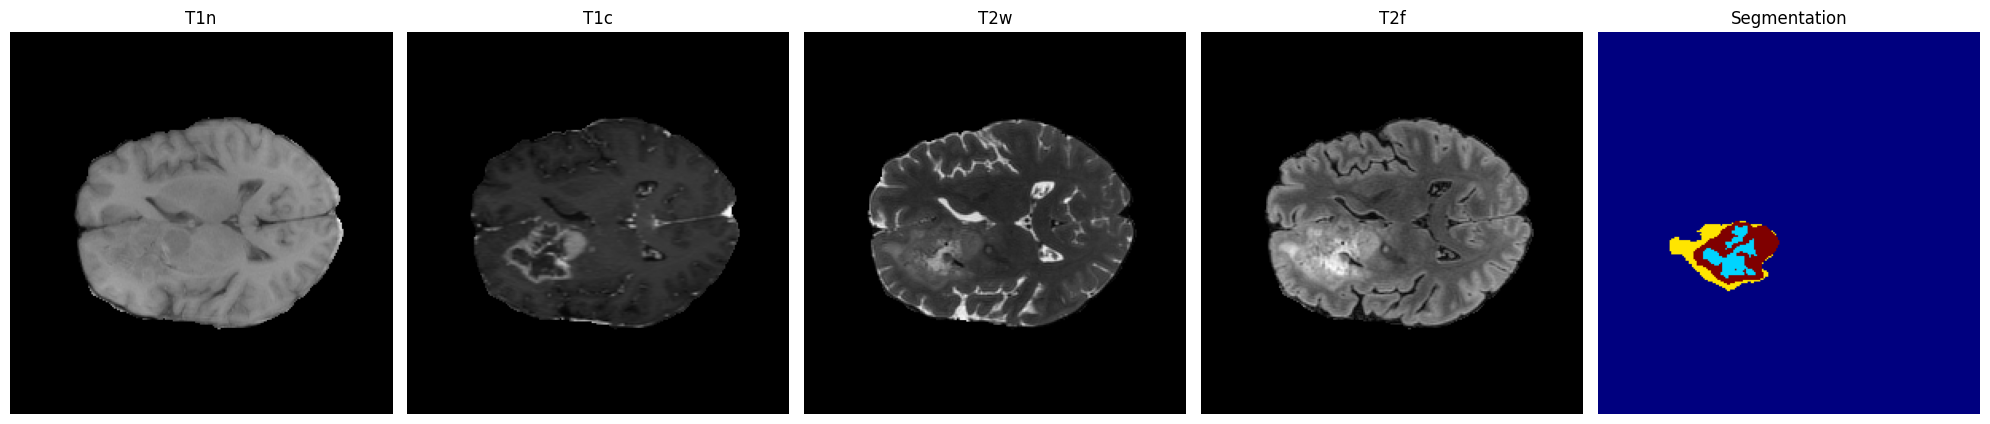

In [18]:
# Cell 15 — Visualize one slice
z = t1n.shape[2] // 2

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(t1n[:, :, z], cmap="gray")
axes[0].set_title("T1n")
axes[0].axis("off")

axes[1].imshow(t1c[:, :, z], cmap="gray")
axes[1].set_title("T1c")
axes[1].axis("off")

axes[2].imshow(t2w[:, :, z], cmap="gray")
axes[2].set_title("T2w")
axes[2].axis("off")

axes[3].imshow(t2f[:, :, z], cmap="gray")
axes[3].set_title("T2f")
axes[3].axis("off")

axes[4].imshow(seg_mc[:, :, z], cmap="jet", vmin=0, vmax=3)
axes[4].set_title("Segmentation")
axes[4].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Cell 16 — Build one 4-channel 2D input from any slice
z = t1n.shape[2] // 2

x_slice = np.stack([
    normalize_slice_01(t1n[:, :, z]),
    normalize_slice_01(t1c[:, :, z]),
    normalize_slice_01(t2w[:, :, z]),
    normalize_slice_01(t2f[:, :, z]),
], axis=-1)

y_slice = seg_mc[:, :, z]

print("Input slice shape:", x_slice.shape)   # (240, 240, 4)
print("Mask slice shape:", y_slice.shape)    # (240, 240)
print("Mask labels:", np.unique(y_slice))

Input slice shape: (240, 240, 4)
Mask slice shape: (240, 240)
Mask labels: [0 1 2 3]


In [20]:
# Cell 17 — Full case loader (corrected)

def normalize_volume_01(vol):
    """
    Robust min-max normalization on a full 3D volume using nonzero voxels only.
    """
    vol = vol.astype(np.float32)
    nz = vol[vol > 0]

    if nz.size == 0:
        return np.zeros_like(vol, dtype=np.float32)

    vmin, vmax = np.percentile(nz, (1, 99))
    vol = np.clip(vol, vmin, vmax)
    vol = (vol - vmin) / (vmax - vmin + 1e-8)
    return vol.astype(np.float32)


def prepare_seg_mask(seg_volume):
    """
    Ensure BraTS mask labels are in {0,1,2,3}.
    If labels are {0,1,2,4}, remap 4 -> 3.
    """
    seg_volume = seg_volume.astype(np.uint8)
    seg_volume = np.where(seg_volume == 4, 3, seg_volume).astype(np.uint8)
    return seg_volume


def load_brats_case(case_row):
    """
    Reads one complete BraTS case from manifest row.
    Applies volume-wise normalization to each modality.
    """
    t1n = nib.load(case_row["t1n_path"]).get_fdata().astype(np.float32)
    t1c = nib.load(case_row["t1c_path"]).get_fdata().astype(np.float32)
    t2w = nib.load(case_row["t2w_path"]).get_fdata().astype(np.float32)
    t2f = nib.load(case_row["t2f_path"]).get_fdata().astype(np.float32)

    seg_raw = np.asanyarray(nib.load(case_row["seg_path"]).dataobj).astype(np.uint8)
    seg_mc = prepare_seg_mask(seg_raw)

    assert t1n.shape == t1c.shape == t2w.shape == t2f.shape == seg_mc.shape, \
        f"Shape mismatch in case {case_row['case_id']}"

    t1n = normalize_volume_01(t1n)
    t1c = normalize_volume_01(t1c)
    t2w = normalize_volume_01(t2w)
    t2f = normalize_volume_01(t2f)

    return {
        "case_id": case_row["case_id"],
        "t1n": t1n,
        "t1c": t1c,
        "t2w": t2w,
        "t2f": t2f,
        "seg_raw": seg_raw,
        "seg_mc": seg_mc
    }

In [21]:
# Cell 18 — Test the full case loader
case_data = load_brats_case(df_complete.iloc[0])

print("Case ID:", case_data["case_id"])
print("T1n shape:", case_data["t1n"].shape)
print("T1c shape:", case_data["t1c"].shape)
print("T2w shape:", case_data["t2w"].shape)
print("T2f shape:", case_data["t2f"].shape)
print("Seg labels:", np.unique(case_data["seg_mc"]))

Case ID: BraTS-GLI-00000-000
T1n shape: (240, 240, 155)
T1c shape: (240, 240, 155)
T2w shape: (240, 240, 155)
T2f shape: (240, 240, 155)
Seg labels: [0 1 2 3]


In [22]:
# Cell 19 — Extract filtered slices from one case

def extract_filtered_slices_from_case(
    case_data,
    drop_empty_brain_slices=True,
    drop_non_tumor_slices=False,
    min_brain_pixels=50
):
    """
    Extract axial 2D slices from one BraTS case with optional filtering.

    Parameters
    ----------
    case_data : dict
        Output of load_brats_case(...)

    drop_empty_brain_slices : bool
        If True, removes slices with too little nonzero MRI content.

    drop_non_tumor_slices : bool
        If True, keeps only slices containing tumor labels > 0.

    min_brain_pixels : int
        Minimum number of nonzero pixels required to consider a slice non-empty.

    Returns
    -------
    X_list, Y_list, meta : lists
    """
    t1n = case_data["t1n"]
    t1c = case_data["t1c"]
    t2w = case_data["t2w"]
    t2f = case_data["t2f"]
    seg = case_data["seg_mc"]
    cid = case_data["case_id"]

    X_list = []
    Y_list = []
    meta = []

    Z = t1n.shape[2]

    for z in range(Z):
        x = np.stack([
            t1n[:, :, z],
            t1c[:, :, z],
            t2w[:, :, z],
            t2f[:, :, z],
        ], axis=-1).astype(np.float32)

        y = seg[:, :, z].astype(np.uint8)

        if drop_empty_brain_slices:
            brain_mask = np.any(x > 0, axis=-1)
            if brain_mask.sum() < min_brain_pixels:
                continue

        if drop_non_tumor_slices:
            if not np.any(y > 0):
                continue

        X_list.append(x)
        Y_list.append(y)
        meta.append({
            "case_id": cid,
            "z": z,
            "has_tumor": bool(np.any(y > 0))
        })

    return X_list, Y_list, meta

In [23]:
# Cell 20 — Test filtered extraction on one case

case_data = load_brats_case(df_complete.iloc[0])

X_list, Y_list, meta = extract_filtered_slices_from_case(
    case_data,
    drop_empty_brain_slices=True,
    drop_non_tumor_slices=False,   # keep both tumor and non-tumor brain slices
    min_brain_pixels=50
)

print("Filtered total slices:", len(X_list))
print("Input shape of one slice:", X_list[0].shape if len(X_list) else None)
print("Mask shape of one slice:", Y_list[0].shape if len(Y_list) else None)
print("Metadata example:", meta[0] if len(meta) else None)
print("Tumor slices kept:", sum(m["has_tumor"] for m in meta))

Filtered total slices: 144
Input shape of one slice: (240, 240, 4)
Mask shape of one slice: (240, 240)
Metadata example: {'case_id': 'BraTS-GLI-00000-000', 'z': 5, 'has_tumor': False}
Tumor slices kept: 47


# Now the TensorFlow 2D pipeline


In [24]:
# Cell 21 — TensorFlow imports
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

2026-04-14 09:08:53.652062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776157733.996138      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776157734.097234      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776157734.932662      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776157734.932710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776157734.932713      55 computation_placer.cc:177] computation placer alr

In [23]:
# # Cell 22 — Check segmentation labels across all complete cases

# all_labels = set()

# for i in range(len(df_complete)):
#     seg_arr = np.asanyarray(nib.load(df_complete.iloc[i]["seg_path"]).dataobj)
#     seg_arr = np.where(seg_arr == 4, 3, seg_arr)
#     all_labels.update(np.unique(seg_arr).tolist())

# print("Global segmentation labels found:", sorted(all_labels))

KeyboardInterrupt: 

In [25]:
# Cell 23 — Three-way case-level split: Train / Val / Test

from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_STATE = 42

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-6

# First split: train vs (val + test)
train_df, temp_df = train_test_split(
    df_complete,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_STATE,
    shuffle=True
)

# Second split: val vs test
relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_ratio,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

# Verify no overlap
train_ids = set(train_df["case_id"])
val_ids   = set(val_df["case_id"])
test_ids  = set(test_df["case_id"])

assert len(train_ids & val_ids)  == 0, "Train/Val overlap!"
assert len(train_ids & test_ids) == 0, "Train/Test overlap!"
assert len(val_ids & test_ids)   == 0, "Val/Test overlap!"

print(f"Training cases:   {len(train_df)}")
print(f"Validation cases: {len(val_df)}")
print(f"Test cases:       {len(test_df)}")
print(f"Total:            {len(train_df) + len(val_df) + len(test_df)}")
print(f"\nNo overlap: ✓")

Training cases:   875
Validation cases: 188
Test cases:       188
Total:            1251

No overlap: ✓


In [26]:
# Cell 24 — Fixed generator + dataset (no data exhaustion)

import gc

NUM_CLASSES    = 4
BATCH_SIZE     = 8
SHUFFLE_BUFFER = 1500


def brats_slice_generator(
    cases_df,
    shuffle_cases=True,
    drop_empty_brain=True,
    min_brain_pixels=50
):
    """
    Yields (x_slice, y_slice) one at a time.
    Only ONE case is in memory at any moment.
    """
    indices = np.arange(len(cases_df))

    if shuffle_cases:
        np.random.shuffle(indices)

    for i in indices:
        case_row = cases_df.iloc[int(i)]

        try:
            case_data = load_brats_case(case_row)
        except Exception as e:
            print(f"⚠ Skipping {case_row['case_id']}: {e}")
            continue

        X_list, Y_list, _ = extract_filtered_slices_from_case(
            case_data,
            drop_empty_brain_slices=drop_empty_brain,
            drop_non_tumor_slices=False,
            min_brain_pixels=min_brain_pixels,
        )

        del case_data
        gc.collect()

        order = np.arange(len(X_list))
        if shuffle_cases:
            np.random.shuffle(order)

        for j in order:
            yield X_list[j], Y_list[j]

        del X_list, Y_list


def make_brats_dataset(
    cases_df,
    batch_size=BATCH_SIZE,
    is_training=True,
    buffer_size=SHUFFLE_BUFFER
):
    sample_shape = nib.load(cases_df.iloc[0]["t1n_path"]).shape
    H, W = sample_shape[0], sample_shape[1]

    def gen():
        return brats_slice_generator(
            cases_df,
            shuffle_cases=is_training,
        )

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=(H, W, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(H, W),    dtype=tf.uint8),
        ),
    )

    if is_training:
        ds = ds.shuffle(buffer_size=buffer_size)

    ds = ds.map(
        lambda x, y: (
            x,
            tf.one_hot(tf.cast(y, tf.int32), depth=NUM_CLASSES)
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [27]:
# Cell 25 — Build datasets

train_ds = make_brats_dataset(train_df, batch_size=BATCH_SIZE, is_training=True)
val_ds   = make_brats_dataset(val_df,   batch_size=BATCH_SIZE, is_training=False)
test_ds  = make_brats_dataset(test_df,  batch_size=BATCH_SIZE, is_training=False)

print("Train dataset:", train_ds)
print("Val   dataset:", val_ds)
print("Test  dataset:", test_ds)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>
Val   dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>
Test  dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None), TensorSpec(shape=(None, 240, 240, 4), dtype=tf.float32, name=None))>


I0000 00:00:1776157769.396290      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [27]:
# Cell 26 — Sanity-check one batch

for xb, yb in train_ds.take(1):
    print("X batch shape:", xb.shape)    # (8, 240, 240, 4)
    print("Y batch shape:", yb.shape)    # (8, 240, 240, 4)
    print("X dtype:", xb.dtype)          # float32
    print("Y dtype:", yb.dtype)          # float32
    print("X range:", tf.reduce_min(xb).numpy(), "→", tf.reduce_max(xb).numpy())
    print("Y unique row:", tf.reduce_sum(yb[0], axis=-1).numpy().max())  # should be 1.0

X batch shape: (8, 240, 240, 4)
Y batch shape: (8, 240, 240, 4)
X dtype: <dtype: 'float32'>
Y dtype: <dtype: 'float32'>
X range: 0.0 → 1.0
Y unique row: 1.0


In [26]:
# Cell 27 — Estimate steps per epoch

AVG_VALID_SLICES_PER_CASE = 120   # conservative estimate for BraTS 240×240×155

est_train_slices = len(train_df) * AVG_VALID_SLICES_PER_CASE
est_val_slices   = len(val_df)   * AVG_VALID_SLICES_PER_CASE

train_steps = est_train_slices // BATCH_SIZE
val_steps   = est_val_slices   // BATCH_SIZE

print(f"Train cases: {len(train_df)}")
print(f"Val   cases: {len(val_df)}")
print(f"Estimated train steps/epoch: {train_steps}")
print(f"Estimated val   steps/epoch: {val_steps}")

Train cases: 875
Val   cases: 188
Estimated train steps/epoch: 13125
Estimated val   steps/epoch: 2820


In [27]:
# Cell 28 — (optional) exact slice count via lightweight pre-scan

def count_valid_slices(cases_df, min_brain_pixels=50):
    """
    Quick pass: load only T1n per case, count non-empty slices.
    """
    total = 0
    for i in range(len(cases_df)):
        vol = nib.load(cases_df.iloc[i]["t1n_path"]).get_fdata(dtype=np.float32)
        Z = vol.shape[2]
        for z in range(Z):
            if np.sum(vol[:, :, z] > 0) >= min_brain_pixels:
                total += 1
        del vol
        if (i + 1) % 100 == 0:
            print(f"Scanned {i+1}/{len(cases_df)}  ({total} slices so far)")
    return total

# Uncomment if you want exact numbers:
exact_train = count_valid_slices(train_df)
exact_val   = count_valid_slices(val_df)
train_steps = exact_train // BATCH_SIZE
val_steps   = exact_val   // BATCH_SIZE
print(f"Exact train slices: {exact_train}, steps: {train_steps}")
print(f"Exact val   slices: {exact_val},   steps: {val_steps}")

Scanned 100/875  (13815 slices so far)
Scanned 200/875  (27575 slices so far)
Scanned 300/875  (41450 slices so far)
Scanned 400/875  (55205 slices so far)
Scanned 500/875  (69009 slices so far)
Scanned 600/875  (82824 slices so far)
Scanned 700/875  (96572 slices so far)
Scanned 800/875  (110417 slices so far)
Scanned 100/188  (13755 slices so far)
Exact train slices: 120793, steps: 15099
Exact val   slices: 25815,   steps: 3226


# Visualizations

Scanned 100/875
Scanned 200/875
Scanned 300/875
Scanned 400/875
Scanned 500/875
Scanned 600/875
Scanned 700/875
Scanned 800/875


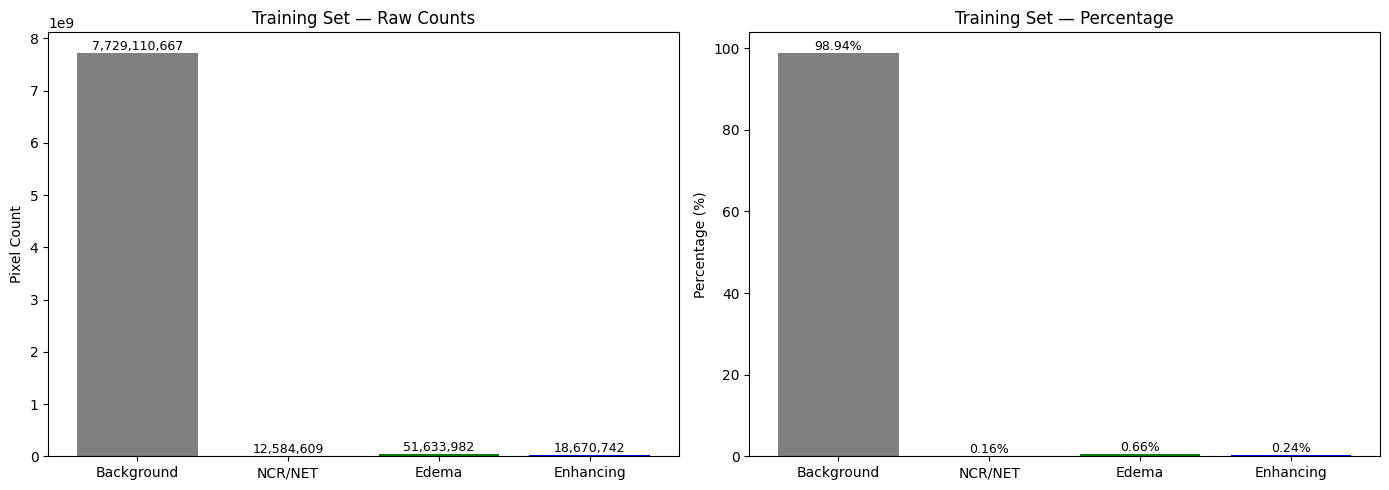

Scanned 100/188


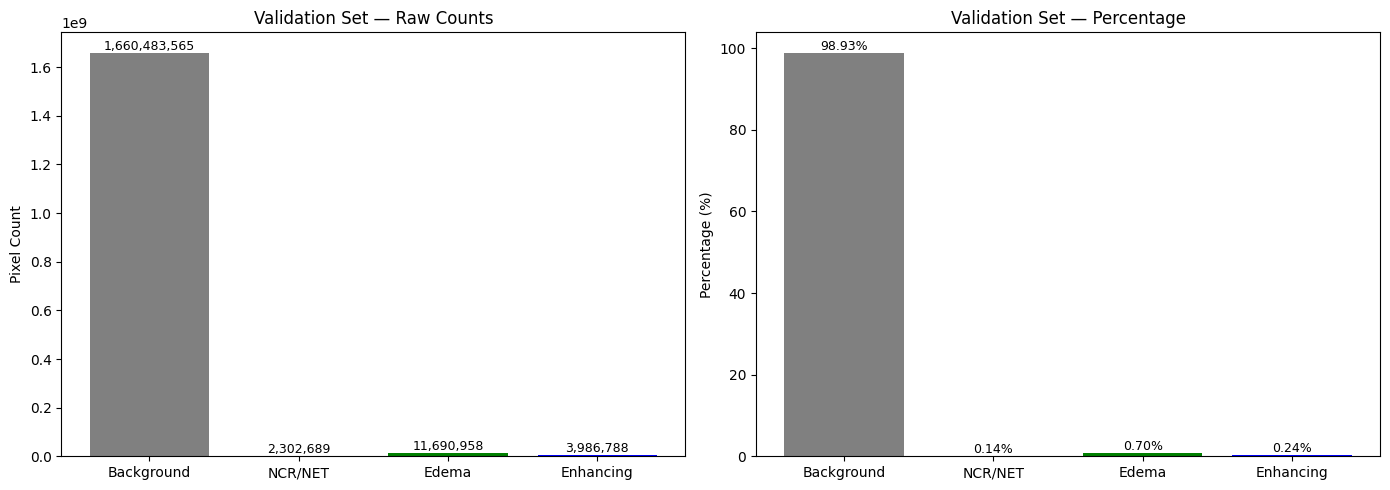

Scanned 100/188


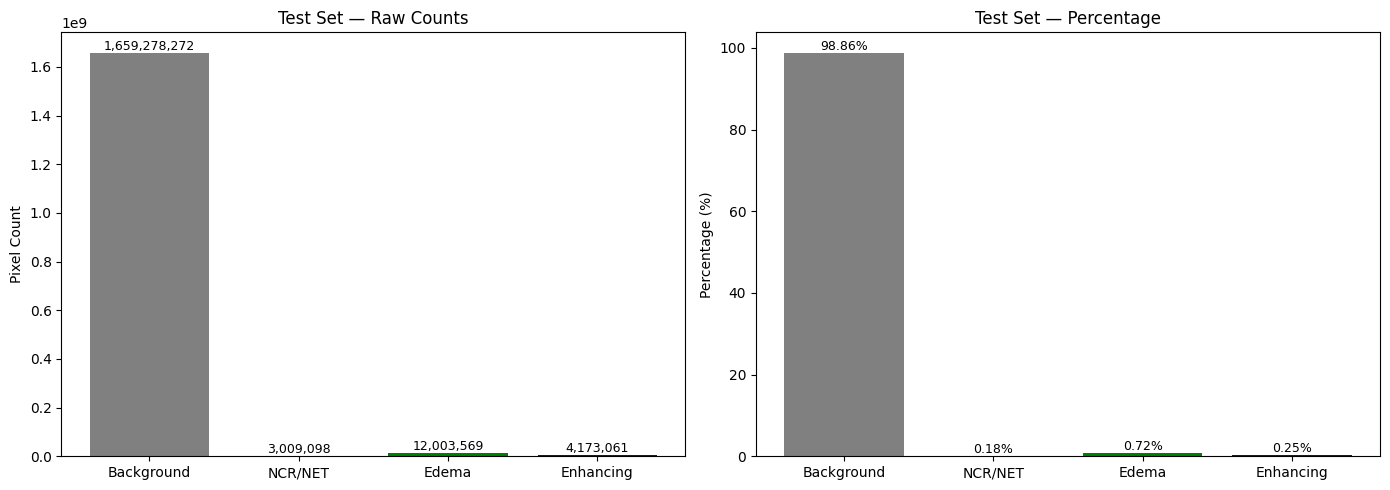

In [42]:
# Viz 1 — Global class pixel distribution (memory-efficient)

def plot_class_distribution_from_df(
    cases_df,
    class_names=None,
    title="Class Pixel Distribution"
):
    """
    Scans segmentation files one at a time.
    Never holds more than one volume in RAM.
    """
    if class_names is None:
        class_names = ["Background", "NCR/NET", "Edema", "Enhancing"]

    global_counts = np.zeros(4, dtype=np.int64)

    for i in range(len(cases_df)):
        seg = np.asanyarray(
            nib.load(cases_df.iloc[i]["seg_path"]).dataobj
        ).astype(np.uint8)
        seg = np.where(seg == 4, 3, seg).astype(np.uint8)

        for c in range(4):
            global_counts[c] += np.sum(seg == c)

        del seg

        if (i + 1) % 100 == 0:
            print(f"Scanned {i+1}/{len(cases_df)}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ["gray", "red", "green", "blue"]

    # Raw counts
    bars = axes[0].bar(class_names, global_counts, color=colors)
    axes[0].set_title(f"{title} — Raw Counts")
    axes[0].set_ylabel("Pixel Count")
    for bar, count in zip(bars, global_counts):
        axes[0].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{count:,}", ha="center", va="bottom", fontsize=9
        )

    # Percentage
    total = global_counts.sum()
    percentages = global_counts / total * 100
    bars2 = axes[1].bar(class_names, percentages, color=colors)
    axes[1].set_title(f"{title} — Percentage")
    axes[1].set_ylabel("Percentage (%)")
    for bar, pct in zip(bars2, percentages):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{pct:.2f}%", ha="center", va="bottom", fontsize=9
        )

    plt.tight_layout()
    plt.show()

# Usage
plot_class_distribution_from_df(train_df, title="Training Set")
plot_class_distribution_from_df(val_df, title="Validation Set")
plot_class_distribution_from_df(test_df, title="Test Set")

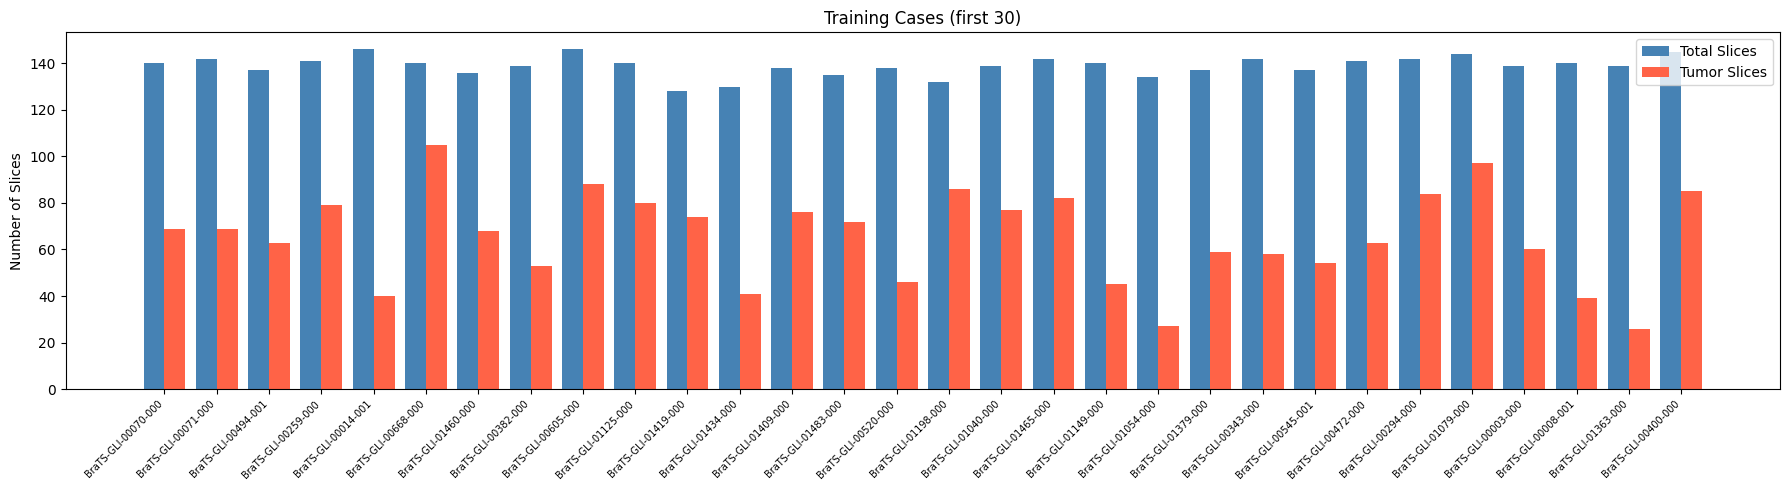

Avg total slices/case: 139.0
Avg tumor slices/case: 65.5
Avg tumor ratio: 47.08%


In [43]:
# Viz 2 — Tumor slices per case (memory-efficient)

def plot_tumor_slices_per_case_from_df(
    cases_df,
    min_brain_pixels=50,
    title="Tumor Slices Per Case"
):
    """
    Loads only seg files. Counts total valid slices and tumor slices per case.
    """
    case_ids = []
    totals = []
    tumors = []

    for i in range(len(cases_df)):
        row = cases_df.iloc[i]
        cid = row["case_id"]

        seg = np.asanyarray(
            nib.load(row["seg_path"]).dataobj
        ).astype(np.uint8)
        seg = np.where(seg == 4, 3, seg).astype(np.uint8)

        # also load one modality to check brain content
        t1n = nib.load(row["t1n_path"]).get_fdata(dtype=np.float32)

        Z = seg.shape[2]
        total_count = 0
        tumor_count = 0

        for z in range(Z):
            brain_pixels = np.sum(t1n[:, :, z] > 0)
            if brain_pixels < min_brain_pixels:
                continue
            total_count += 1
            if np.any(seg[:, :, z] > 0):
                tumor_count += 1

        case_ids.append(cid)
        totals.append(total_count)
        tumors.append(tumor_count)

        del seg, t1n

    x = np.arange(len(case_ids))
    width = 0.4

    fig, ax = plt.subplots(figsize=(max(8, len(case_ids) * 0.6), 5))
    ax.bar(x - width / 2, totals, width, label="Total Slices", color="steelblue")
    ax.bar(x + width / 2, tumors, width, label="Tumor Slices", color="tomato")

    # only show labels if not too many cases
    if len(case_ids) <= 30:
        ax.set_xticks(x)
        ax.set_xticklabels(case_ids, rotation=45, ha="right", fontsize=7)
    else:
        ax.set_xlabel("Case Index")

    ax.set_ylabel("Number of Slices")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # also print summary
    print(f"Avg total slices/case: {np.mean(totals):.1f}")
    print(f"Avg tumor slices/case: {np.mean(tumors):.1f}")
    print(f"Avg tumor ratio: {np.mean(np.array(tumors)/np.array(totals)):.2%}")

# Usage (use a subset if you have many cases)
# For speed, visualize only first 30 cases:
plot_tumor_slices_per_case_from_df(
    train_df.iloc[:30],
    title="Training Cases (first 30)"
)

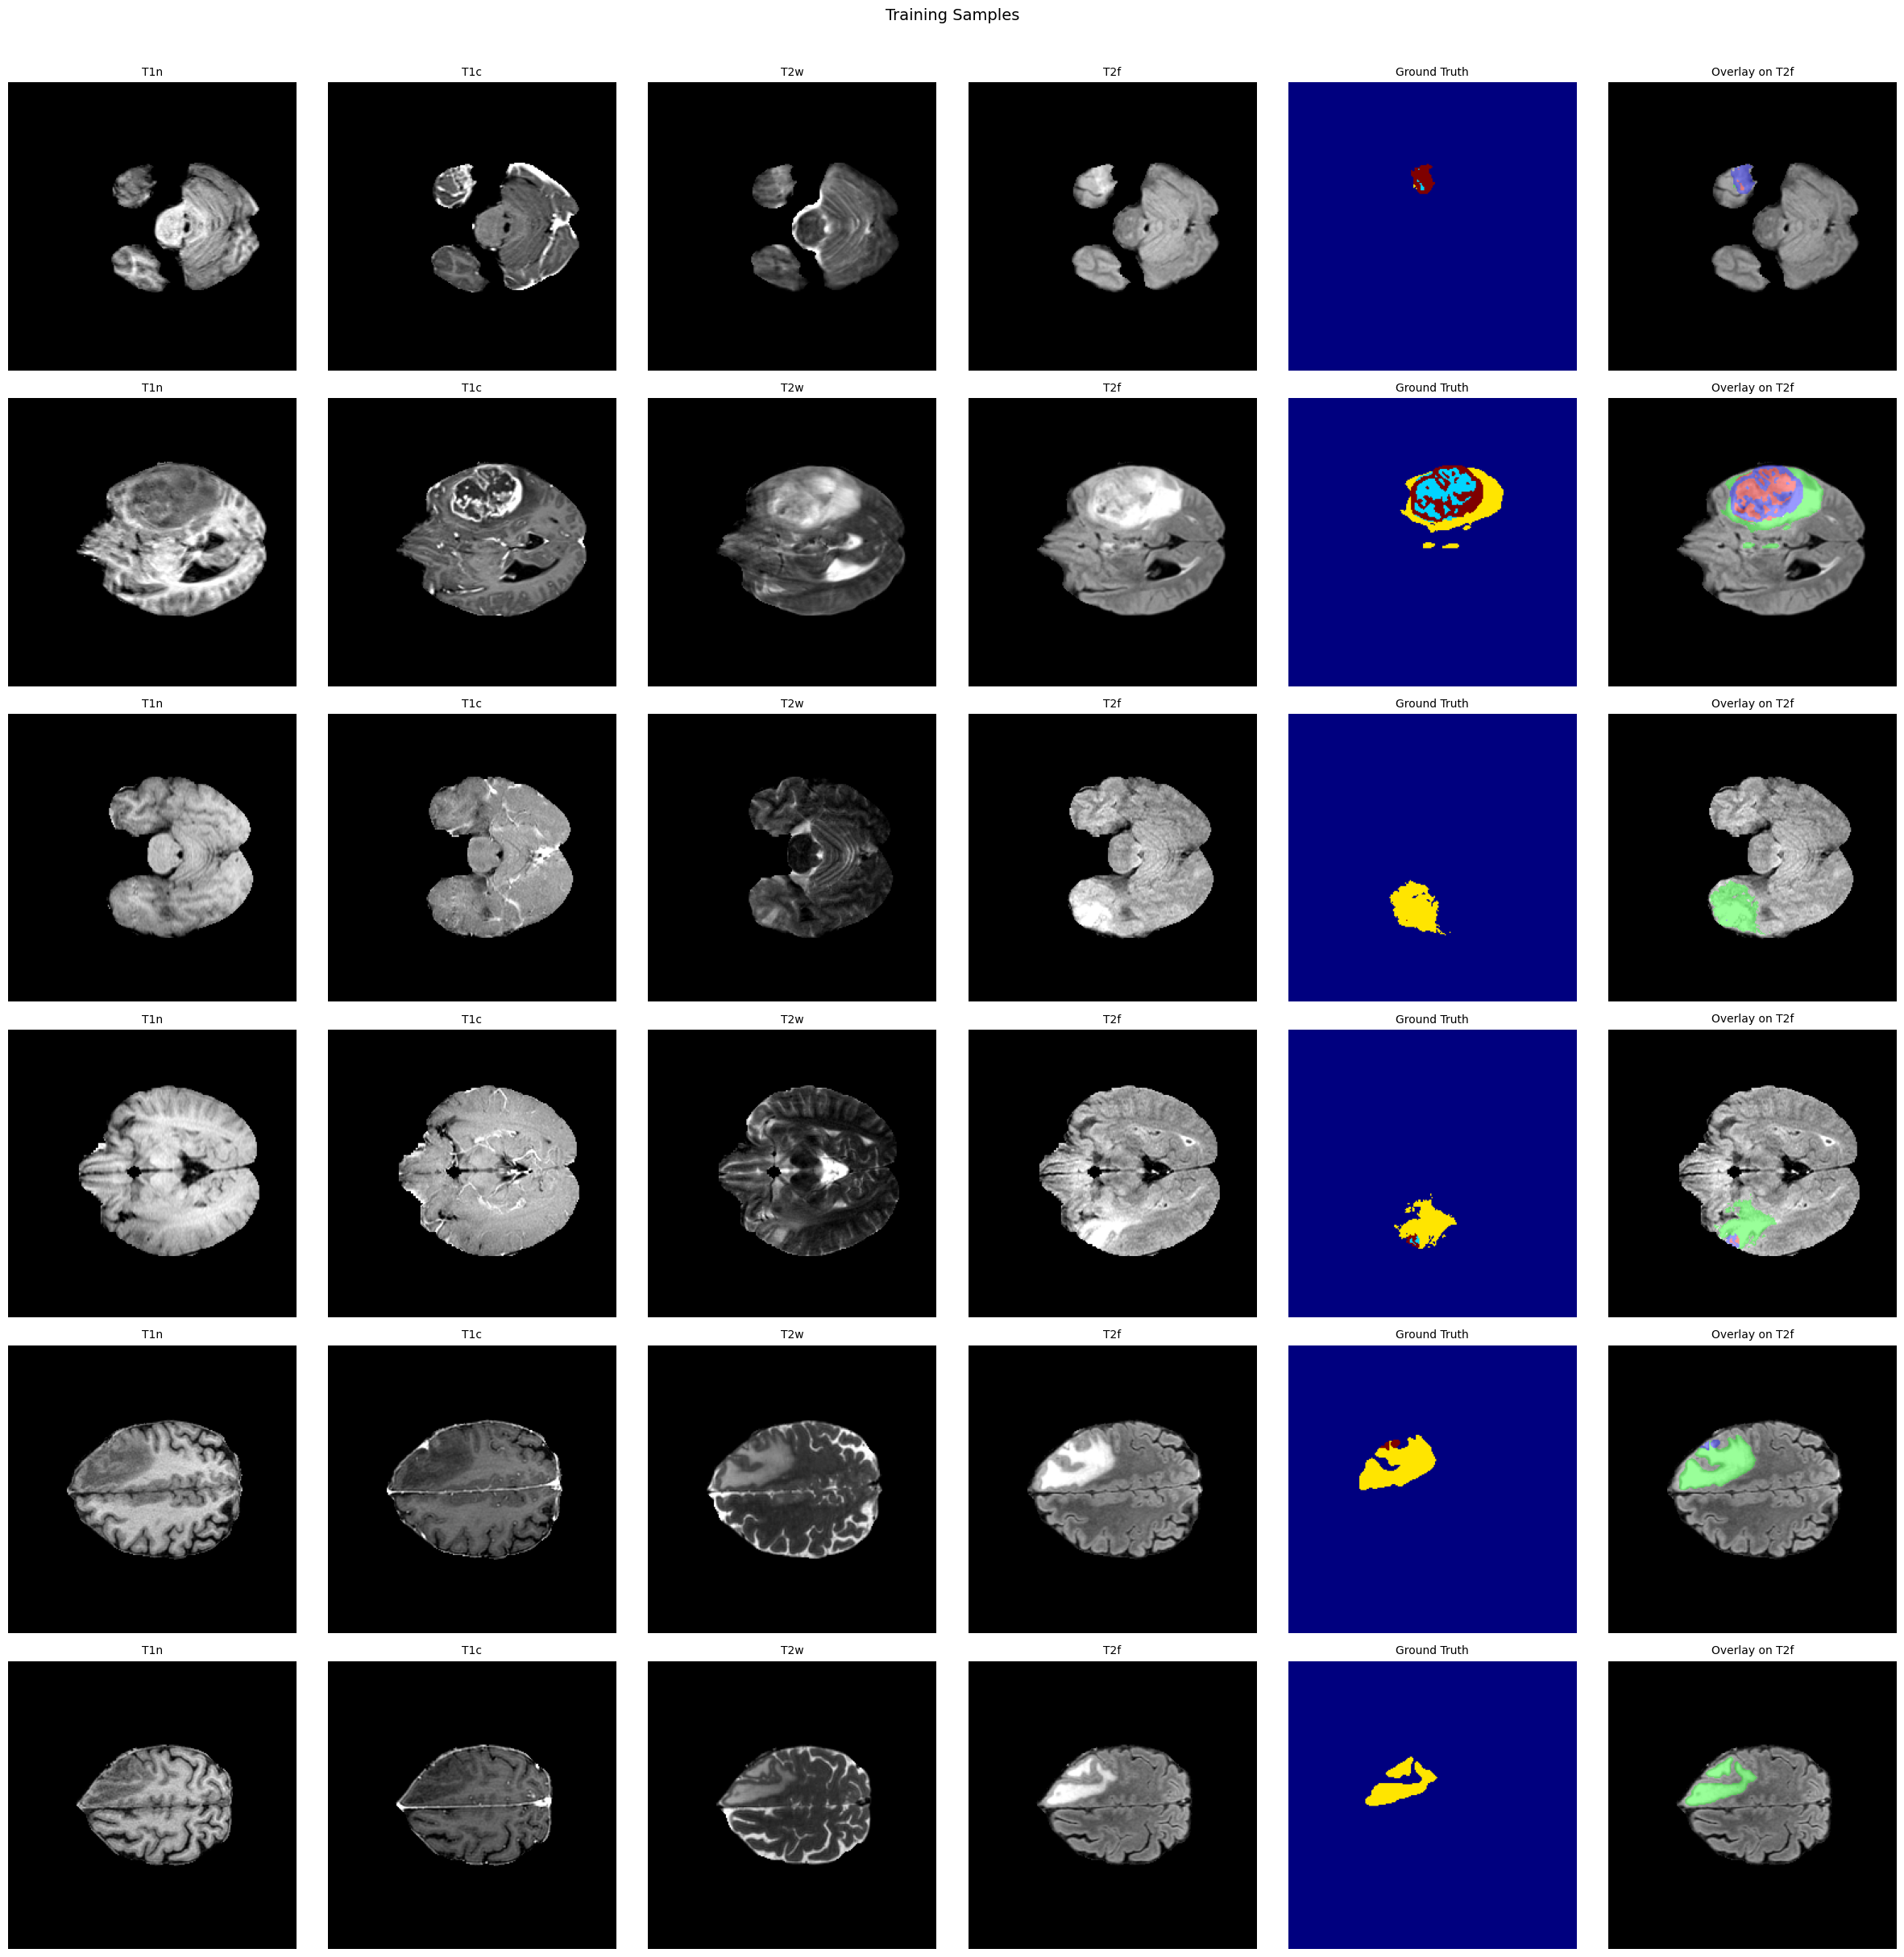

In [44]:
# Viz 3 — Sample slices with overlay (loads only a few cases)

def plot_sample_slices_with_overlay_efficient(
    cases_df,
    num_cases=3,
    slices_per_case=2,
    class_colors=None,
    title="Sample Slices"
):
    """
    Loads a few random cases, picks tumor slices, and displays them.
    """
    if class_colors is None:
        class_colors = {
            0: [0, 0, 0],
            1: [255, 0, 0],
            2: [0, 255, 0],
            3: [0, 0, 255],
        }

    modality_names = ["T1n", "T1c", "T2w", "T2f"]
    num_cases = min(num_cases, len(cases_df))
    chosen_cases = cases_df.sample(n=num_cases, random_state=42)

    all_rows = []  # collect (x_slice, y_slice) pairs

    for _, row in chosen_cases.iterrows():
        case_data = load_brats_case(row)
        X_list, Y_list, _ = extract_filtered_slices_from_case(
            case_data,
            drop_empty_brain_slices=True,
            drop_non_tumor_slices=True,   # only tumor slices for visualization
            min_brain_pixels=50
        )
        del case_data
        gc.collect()

        if len(X_list) == 0:
            continue

        indices = np.random.choice(
            len(X_list),
            min(slices_per_case, len(X_list)),
            replace=False
        )
        for idx in indices:
            all_rows.append((X_list[idx], Y_list[idx]))

        del X_list, Y_list

    if len(all_rows) == 0:
        print("No tumor slices found.")
        return

    fig, axes = plt.subplots(len(all_rows), 6, figsize=(24, 4 * len(all_rows)))

    if len(all_rows) == 1:
        axes = axes[np.newaxis, :]

    for r, (x_slice, y_slice) in enumerate(all_rows):

        # 4 modalities
        for col in range(4):
            axes[r, col].imshow(x_slice[:, :, col], cmap="gray")
            axes[r, col].set_title(modality_names[col], fontsize=10)
            axes[r, col].axis("off")

        # Segmentation mask
        axes[r, 4].imshow(y_slice, cmap="jet", vmin=0, vmax=3)
        axes[r, 4].set_title("Ground Truth", fontsize=10)
        axes[r, 4].axis("off")

        # Overlay on T2f
        base = x_slice[:, :, 3]
        rgb = np.stack([base, base, base], axis=-1)

        overlay = np.zeros((*y_slice.shape, 3), dtype=np.float32)
        for label, color in class_colors.items():
            if label == 0:
                continue
            mask = y_slice == label
            overlay[mask] = [c / 255.0 for c in color]

        alpha = 0.4
        blended = np.where(
            overlay.sum(axis=-1, keepdims=True) > 0,
            rgb * (1 - alpha) + overlay * alpha,
            rgb
        )
        blended = np.clip(blended, 0, 1)

        axes[r, 5].imshow(blended)
        axes[r, 5].set_title("Overlay on T2f", fontsize=10)
        axes[r, 5].axis("off")

    plt.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

# Usage
import gc
plot_sample_slices_with_overlay_efficient(
    train_df, num_cases=3, slices_per_case=2, title="Training Samples"
)

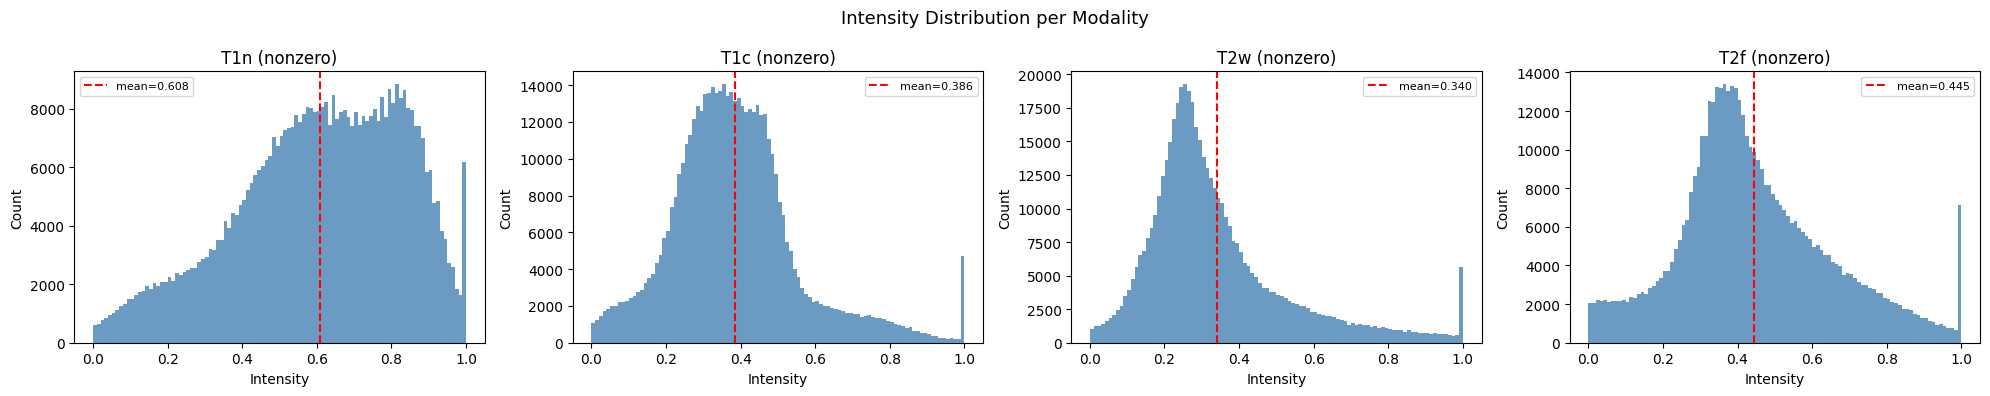

In [45]:
# Viz 4 — Intensity histograms from tf.data (no full array needed)

def plot_modality_intensity_histograms_from_ds(
    dataset,
    num_batches=50,
    title="Intensity Distribution per Modality"
):
    """
    Samples a few batches from tf.data and plots intensity distributions.
    """
    modality_names = ["T1n", "T1c", "T2w", "T2f"]

    # collect intensities
    collected = {ch: [] for ch in range(4)}

    for xb, yb in dataset.take(num_batches):
        x_np = xb.numpy()
        for ch in range(4):
            vals = x_np[:, :, :, ch]
            nz = vals[vals > 0].ravel()
            if len(nz) > 0:
                # subsample to avoid huge arrays
                if len(nz) > 10000:
                    nz = np.random.choice(nz, 10000, replace=False)
                collected[ch].append(nz)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    for ch in range(4):
        values = np.concatenate(collected[ch])

        axes[ch].hist(values, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
        axes[ch].set_title(f"{modality_names[ch]} (nonzero)")
        axes[ch].set_xlabel("Intensity")
        axes[ch].set_ylabel("Count")
        axes[ch].axvline(
            values.mean(), color="red", linestyle="--",
            label=f"mean={values.mean():.3f}"
        )
        axes[ch].legend(fontsize=8)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

# Usage
plot_modality_intensity_histograms_from_ds(train_ds, num_batches=50)

Scanned 100/875
Scanned 200/875
Scanned 300/875
Scanned 400/875
Scanned 500/875
Scanned 600/875
Scanned 700/875
Scanned 800/875


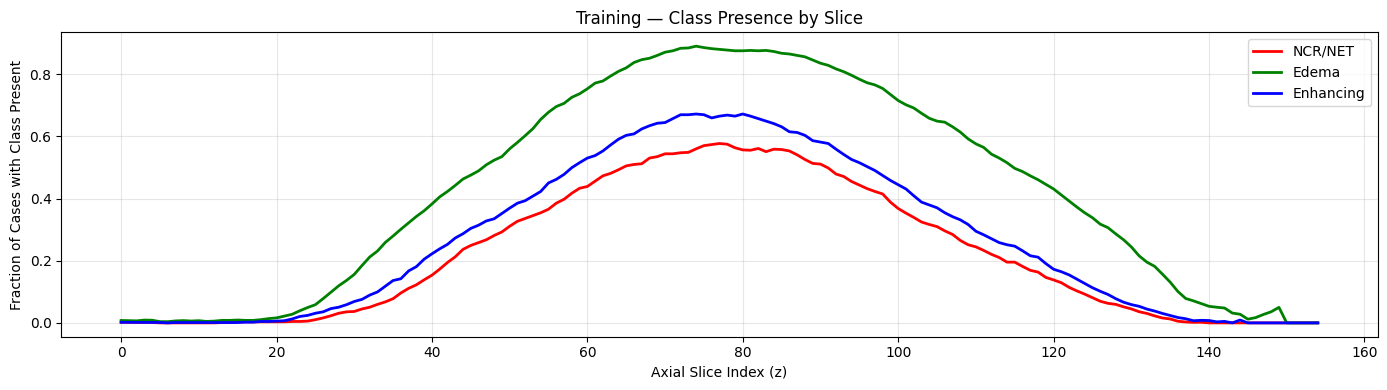

In [46]:
# Viz 5 — Class presence by slice index (memory-efficient)

def plot_class_presence_by_slice_from_df(
    cases_df,
    min_brain_pixels=50,
    title="Class Presence by Slice Index"
):
    """
    Scans seg + t1n files one case at a time.
    """
    class_names = ["Background", "NCR/NET", "Edema", "Enhancing"]

    # assume standard BraTS depth
    Z_MAX = 155
    presence = np.zeros((4, Z_MAX), dtype=np.float32)
    counts_per_z = np.zeros(Z_MAX, dtype=np.float32)

    for i in range(len(cases_df)):
        row = cases_df.iloc[i]

        seg = np.asanyarray(
            nib.load(row["seg_path"]).dataobj
        ).astype(np.uint8)
        seg = np.where(seg == 4, 3, seg).astype(np.uint8)

        t1n = nib.load(row["t1n_path"]).get_fdata(dtype=np.float32)

        Z = min(seg.shape[2], Z_MAX)

        for z in range(Z):
            if np.sum(t1n[:, :, z] > 0) < min_brain_pixels:
                continue
            counts_per_z[z] += 1
            labels_in_slice = np.unique(seg[:, :, z])
            for l in labels_in_slice:
                if l < 4:
                    presence[l, z] += 1

        del seg, t1n

        if (i + 1) % 100 == 0:
            print(f"Scanned {i+1}/{len(cases_df)}")

    safe_counts = np.where(counts_per_z > 0, counts_per_z, 1)
    presence_pct = presence / safe_counts[np.newaxis, :]

    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ["gray", "red", "green", "blue"]
    for c in range(1, 4):
        ax.plot(presence_pct[c], label=class_names[c], linewidth=2, color=colors[c])

    ax.set_xlabel("Axial Slice Index (z)")
    ax.set_ylabel("Fraction of Cases with Class Present")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage
plot_class_presence_by_slice_from_df(train_df, title="Training — Class Presence by Slice")

Scanned 100/875
Scanned 200/875
Scanned 300/875
Scanned 400/875
Scanned 500/875
Scanned 600/875
Scanned 700/875
Scanned 800/875


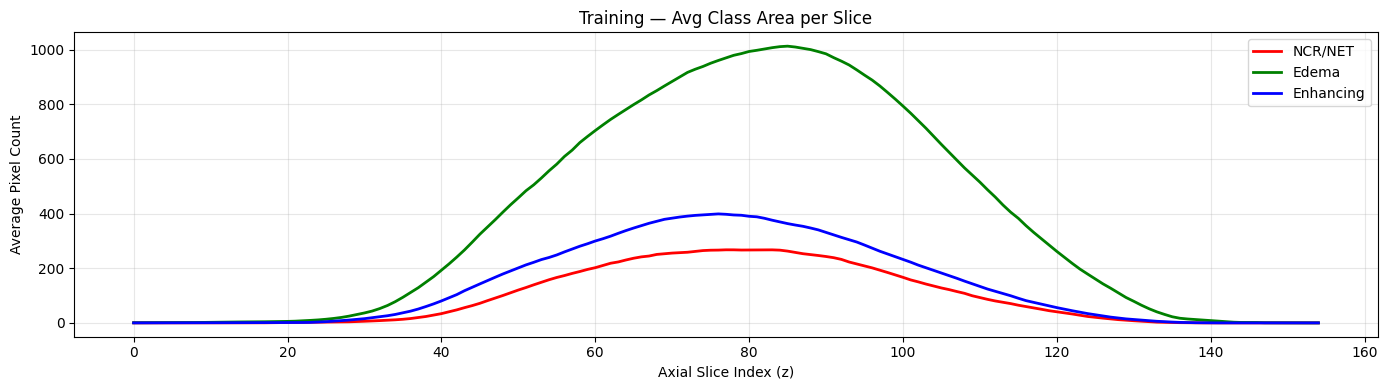

In [47]:
# Viz 6 — Average class area per slice (memory-efficient)

def plot_avg_class_area_per_slice_from_df(
    cases_df,
    min_brain_pixels=50,
    title="Average Class Area per Slice"
):
    """
    Scans seg + t1n files one case at a time.
    """
    class_names = ["Background", "NCR/NET", "Edema", "Enhancing"]

    Z_MAX = 155
    area_sum = np.zeros((4, Z_MAX), dtype=np.float64)
    area_cnt = np.zeros(Z_MAX, dtype=np.float64)

    for i in range(len(cases_df)):
        row = cases_df.iloc[i]

        seg = np.asanyarray(
            nib.load(row["seg_path"]).dataobj
        ).astype(np.uint8)
        seg = np.where(seg == 4, 3, seg).astype(np.uint8)

        t1n = nib.load(row["t1n_path"]).get_fdata(dtype=np.float32)

        Z = min(seg.shape[2], Z_MAX)

        for z in range(Z):
            if np.sum(t1n[:, :, z] > 0) < min_brain_pixels:
                continue
            area_cnt[z] += 1
            for c in range(4):
                area_sum[c, z] += np.sum(seg[:, :, z] == c)

        del seg, t1n

        if (i + 1) % 100 == 0:
            print(f"Scanned {i+1}/{len(cases_df)}")

    safe_cnt = np.where(area_cnt > 0, area_cnt, 1)
    area_avg = area_sum / safe_cnt[np.newaxis, :]

    fig, ax = plt.subplots(figsize=(14, 4))
    colors = ["gray", "red", "green", "blue"]
    for c in range(1, 4):
        ax.plot(area_avg[c], label=class_names[c], linewidth=2, color=colors[c])

    ax.set_xlabel("Axial Slice Index (z)")
    ax.set_ylabel("Average Pixel Count")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Usage
plot_avg_class_area_per_slice_from_df(
    train_df, title="Training — Avg Class Area per Slice"
)

In [28]:
# Cell 29 — Loss functions (Strategy D: Dice + Weighted CE)

import tensorflow.keras.backend as K

# ────────────────────────────────────────────
# 1. Class weights (from your Viz 1 output)
# ────────────────────────────────────────────

pixel_counts = {
    0: 7_729_110_667,   # background
    1: 12_584_609,       # NCR/NET
    2: 51_633_982,       # edema
    3: 18_670_742,       # enhancing
}

def compute_class_weights(counts, mode="sqrt_inv"):
    """
    Compute class weights from pixel counts.
    
    Modes:
      'inv'      — raw inverse frequency (can be too extreme)
      'sqrt_inv' — sqrt of inverse frequency (recommended)
      'log_inv'  — log of inverse frequency (gentler)
    """
    total = sum(counts.values())
    n = len(counts)

    raw_weights = {c: total / (n * count) for c, count in counts.items()}

    if mode == "inv":
        weights = raw_weights
    elif mode == "sqrt_inv":
        weights = {c: np.sqrt(w) for c, w in raw_weights.items()}
    elif mode == "log_inv":
        weights = {c: np.log(1 + w) for c, w in raw_weights.items()}
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # normalize so min weight = 1.0
    min_w = min(weights.values())
    weights = {c: w / min_w for c, w in weights.items()}

    return weights


class_weights = compute_class_weights(pixel_counts, mode="sqrt_inv")
print("Class weights (sqrt inverse frequency):")
for c, w in class_weights.items():
    print(f"  Class {c}: {w:.4f}")

CLASS_WEIGHT_TENSOR = tf.constant(
    [class_weights[c] for c in range(NUM_CLASSES)],
    dtype=tf.float32
)

# ────────────────────────────────────────────
# 2. Dice loss
# ────────────────────────────────────────────

def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Soft Dice loss averaged over all classes including background.
    
    y_true: (B, H, W, C) one-hot
    y_pred: (B, H, W, C) softmax
    """
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)        # (B, C)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    dice_per_class = (2.0 * intersection + smooth) / (union + smooth) # (B, C)

    mean_dice = tf.reduce_mean(dice_per_class, axis=-1)               # (B,)
    return 1.0 - tf.reduce_mean(mean_dice)                            # scalar


# ────────────────────────────────────────────
# 3. Weighted categorical cross-entropy
# ────────────────────────────────────────────

def weighted_ce(y_true, y_pred):
    """
    Weighted categorical cross-entropy.
    """
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    ce = -y_true * tf.math.log(y_pred)                    # (B, H, W, C)
    weighted = ce * CLASS_WEIGHT_TENSOR                    # broadcast
    return tf.reduce_mean(tf.reduce_sum(weighted, axis=-1))


# ────────────────────────────────────────────
# 4. Combined loss
# ────────────────────────────────────────────

DICE_WEIGHT = 0.5
CE_WEIGHT   = 0.5

def combined_loss(y_true, y_pred):
    """
    Combined Dice loss + Weighted cross-entropy.
    """
    return DICE_WEIGHT * dice_loss(y_true, y_pred) + CE_WEIGHT * weighted_ce(y_true, y_pred)

print("\nLoss function ready: combined_loss (Dice + Weighted CE)")

Class weights (sqrt inverse frequency):
  Class 0: 1.0000
  Class 1: 24.7825
  Class 2: 12.2348
  Class 3: 20.3462

Loss function ready: combined_loss (Dice + Weighted CE)


In [29]:
# Cell 30 — Dice coefficient metrics for monitoring

def dice_coef(y_true, y_pred, smooth=1e-6):
    """Mean Dice over tumor classes only (1, 2, 3). Skips background."""
    y_true_f = tf.reshape(y_true, [tf.shape(y_true)[0], -1, NUM_CLASSES])
    y_pred_f = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1, NUM_CLASSES])

    intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=1)
    union = tf.reduce_sum(y_true_f, axis=1) + tf.reduce_sum(y_pred_f, axis=1)

    dice_per_class = (2.0 * intersection + smooth) / (union + smooth)

    # only tumor classes: columns 1, 2, 3
    tumor_dice = dice_per_class[:, 1:]
    return tf.reduce_mean(tumor_dice)


def _dice_single(y_true, y_pred, class_idx, smooth=1e-6):
    y_t = y_true[..., class_idx]
    y_p = y_pred[..., class_idx]
    y_t_f = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p_f = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    inter = tf.reduce_sum(y_t_f * y_p_f, axis=1)
    union = tf.reduce_sum(y_t_f, axis=1) + tf.reduce_sum(y_p_f, axis=1)
    return tf.reduce_mean((2.0 * inter + smooth) / (union + smooth))


def dice_ncr(y_true, y_pred):
    """Dice — NCR/NET (class 1)"""
    return _dice_single(y_true, y_pred, 1)

def dice_ed(y_true, y_pred):
    """Dice — Edema (class 2)"""
    return _dice_single(y_true, y_pred, 2)

def dice_et(y_true, y_pred):
    """Dice — Enhancing Tumor (class 3)"""
    return _dice_single(y_true, y_pred, 3)

print("Metrics ready: dice_coef, dice_ncr, dice_ed, dice_et")

Metrics ready: dice_coef, dice_ncr, dice_ed, dice_et


# U-Net baseline

In [ ]:
# Cell 31 — U-Net model for 2D BraTS segmentation

from tensorflow.keras import layers, Model


def conv_block(x, filters, dropout_rate=0.0):
    """Two 3×3 convolutions + BatchNorm + ReLU."""
    x = layers.Conv2D(
        filters, (3, 3), padding="same", kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters, (3, 3), padding="same", kernel_initializer="he_normal"
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x


def encoder_block(x, filters, dropout_rate=0.0):
    """Conv block → skip connection + MaxPool."""
    skip = conv_block(x, filters, dropout_rate)
    pool = layers.MaxPooling2D((2, 2))(skip)
    return skip, pool


def decoder_block(x, skip, filters, dropout_rate=0.0):
    """Upsample → concatenate skip → conv block."""
    x = layers.Conv2DTranspose(
        filters, (2, 2), strides=(2, 2), padding="same"
    )(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x


def build_unet(
    input_shape=(240, 240, 4),
    num_classes=4,
    filters=(64, 128, 256, 512),
    bottleneck_filters=1024,
    dropout_encoder=0.1,
    dropout_bottleneck=0.3,
    dropout_decoder=0.1
):
    """
    Standard U-Net with 4 encoder levels.

    Architecture:
        Input (240, 240, 4)
        
        Encoder:
            Level 1 — 64  → pool → 120×120
            Level 2 — 128 → pool → 60×60
            Level 3 — 256 → pool → 30×30
            Level 4 — 512 → pool → 15×15

        Bottleneck — 1024 at 15×15

        Decoder:
            Level 4 — 512  at 30×30
            Level 3 — 256  at 60×60
            Level 2 — 128  at 120×120
            Level 1 — 64   at 240×240

        Output — softmax (240, 240, 4)

    Total params: ~31M (with default filters)
    """
    inputs = layers.Input(shape=input_shape)

    # ── Encoder ──
    skips = []
    x = inputs

    for i, f in enumerate(filters):
        skip, x = encoder_block(x, f, dropout_rate=dropout_encoder)
        skips.append(skip)

    # ── Bottleneck ──
    x = conv_block(x, bottleneck_filters, dropout_rate=dropout_bottleneck)

    # ── Decoder ──
    for i, f in enumerate(reversed(filters)):
        skip = skips[-(i + 1)]
        x = decoder_block(x, skip, f, dropout_rate=dropout_decoder)

    # ── Output ──
    outputs = layers.Conv2D(
        num_classes, (1, 1), activation="softmax", dtype="float32"
    )(x)

    model = Model(inputs, outputs, name="UNet_BraTS_2D")
    return model


# Dimension walkthrough:
#   Input:      240 × 240 × 4
#   Enc1:       240 × 240 × 64    → pool → 120 × 120
#   Enc2:       120 × 120 × 128   → pool → 60  × 60
#   Enc3:       60  × 60  × 256   → pool → 30  × 30
#   Enc4:       30  × 30  × 512   → pool → 15  × 15
#   Bottleneck: 15  × 15  × 1024
#   Dec4:       30  × 30  × 512   (concat Enc4 skip)
#   Dec3:       60  × 60  × 256   (concat Enc3 skip)
#   Dec2:       120 × 120 × 128   (concat Enc2 skip)
#   Dec1:       240 × 240 × 64    (concat Enc1 skip)
#   Output:     240 × 240 × 4     (softmax)

print("U-Net architecture defined.")

U-Net architecture defined.


In [ ]:
# Cell 32 — Build and compile the model

model = build_unet(
    input_shape=(240, 240, 4),
    num_classes=NUM_CLASSES,
    filters=(64, 128, 256, 512),
    bottleneck_filters=1024,
    dropout_encoder=0.1,
    dropout_bottleneck=0.3,
    dropout_decoder=0.1
)

LEARNING_RATE = 1e-4

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
)

model.summary()

# Quick parameter count
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Approx model size: {total_params * 4 / 1024**2:.1f} MB (float32)")

Model: "UNet_BraTS_2D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 240, 240,  │      2,368 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 240, 240,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 240, 240,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 240, 240,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 240, 240,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 240, 240,  │          0 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 120, 120,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 120, 120,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 120, 120,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 120, 120,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 120, 120,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 120, 120,  │          0 │ activation_3[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 60, 60,    │          0 │ dropout_1[0][0] 

 Total params: 31,056,068 (118.47 MB)

 Trainable params: 31,044,292 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)


Total parameters: 31,056,068
Approx model size: 118.5 MB (float32)


In [ ]:
# Lighter alternative (uncomment if OOM)
# model = build_unet(
#     input_shape=(240, 240, 4),
#     num_classes=NUM_CLASSES,
#     filters=(32, 64, 128, 256),
#     bottleneck_filters=512,
#     dropout_encoder=0.1,
#     dropout_bottleneck=0.3,
#     dropout_decoder=0.1
# )

In [28]:
# # Cell 33 — Training callbacks

# from tensorflow.keras.callbacks import (
#     ModelCheckpoint,
#     EarlyStopping,
#     ReduceLROnPlateau,
#     CSVLogger
# )

# CHECKPOINT_PATH = "/kaggle/working/unet_brats_best.keras"
# LOG_PATH        = "/kaggle/working/training_log.csv"

# callbacks = [
#     # Save best model based on validation Dice
#     ModelCheckpoint(
#         filepath=CHECKPOINT_PATH,
#         monitor="val_dice_coef",
#         mode="max",
#         save_best_only=True,
#         verbose=1
#     ),

#     # Stop early if val Dice does not improve for 7 epochs
#     EarlyStopping(
#         monitor="val_dice_coef",
#         mode="max",
#         patience=7,
#         restore_best_weights=True,
#         verbose=1
#     ),

#     # Reduce LR when val Dice plateaus
#     ReduceLROnPlateau(
#         monitor="val_dice_coef",
#         mode="max",
#         factor=0.5,
#         patience=3,
#         min_lr=1e-7,
#         verbose=1
#     ),

#     # Log metrics to CSV
#     CSVLogger(LOG_PATH, separator=",", append=False),
# ]

# print("Callbacks configured:")
# print(f"  Checkpoint: {CHECKPOINT_PATH}")
# print(f"  CSV log:    {LOG_PATH}")
# print(f"  EarlyStopping patience: 7 epochs")
# print(f"  ReduceLR patience: 3 epochs, factor: 0.5")

Callbacks configured:
  Checkpoint: /kaggle/working/unet_brats_best.keras
  CSV log:    /kaggle/working/training_log.csv
  EarlyStopping patience: 7 epochs
  ReduceLR patience: 3 epochs, factor: 0.5


In [53]:
# # Cell 34 — Training

# # ── Step estimates ──
# AVG_TUMOR_SLICES    = 50
# AVG_NONTUMOR_SLICES = 70
# OVERSAMPLE_FACTOR   = 3
# KEEP_RATIO          = 0.3

# est_slices_per_case_train = (
#     AVG_TUMOR_SLICES * OVERSAMPLE_FACTOR +
#     int(AVG_NONTUMOR_SLICES * KEEP_RATIO)
# )
# AVG_SLICES_PER_CASE_VAL = 120

# train_steps = (len(train_df) * est_slices_per_case_train) // BATCH_SIZE
# val_steps   = (len(val_df)   * AVG_SLICES_PER_CASE_VAL)   // BATCH_SIZE

# EPOCHS = 50

# print(f"Training cases:    {len(train_df)}")
# print(f"Validation cases:  {len(val_df)}")
# print(f"Test cases:        {len(test_df)}")
# print(f"Batch size:        {BATCH_SIZE}")
# print(f"Est train steps:   {train_steps}")
# print(f"Est val steps:     {val_steps}")
# print(f"Max epochs:        {EPOCHS}")
# print(f"Est time/epoch:    ~{train_steps * 0.4 / 60:.0f} min (rough)")
# print()

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     steps_per_epoch=train_steps,
#     validation_steps=val_steps,
#     callbacks=callbacks,
#     verbose=1
# )

Training cases:    875
Validation cases:  188
Test cases:        188
Batch size:        8
Est train steps:   18703
Est val steps:     2820
Max epochs:        50
Est time/epoch:    ~125 min (rough)

Epoch 1/50


I0000 00:00:1775909217.031158     134 service.cc:152] XLA service 0x7ddecc0029f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775909217.031212     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775909219.522165     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775909253.865293     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18703/18703 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - dice_coef: 0.4170 - dice_ed: 0.5708 - dice_et: 0.3964 - dice_ncr: 0.2837 - loss: 0.2933
Epoch 1: val_dice_coef improved from -inf to 0.24430, saving model to /kaggle/working/unet_brats_best.keras
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 4552s 240ms/step - dice_coef: 0.4170 - dice_ed: 0.5708 - dice_et: 0.3964 - dice_ncr: 0.2837 - loss: 0.2933 - val_dice_coef: 0.2443 - val_dice_ed: 0.3430 - val_dice_et: 0.2342 - val_dice_ncr: 0.1556 - val_loss: 0.3418 - learning_rate: 1.0000e-04
Epoch 2/50
 5053/18703 ━━━━━━━━━━━━━━━━━━━━ 49:35 218ms/step - dice_coef: 0.5037 - dice_ed: 0.7029 - dice_et: 0.4550 - dice_ncr: 0.3533 - loss: 0.2226

2026-04-11 13:40:46.088786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 13:40:46.321190: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 5054/18703 ━━━━━━━━━━━━━━━━━━━━ 50:34 222ms/step - dice_coef: 0.5037 - dice_ed: 0.7029 - dice_et: 0.4550 - dice_ncr: 0.3533 - loss: 0.2226

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_dice_coef did not improve from 0.24430
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 1534s 82ms/step - dice_coef: 0.5068 - dice_ed: 0.6998 - dice_et: 0.4584 - dice_ncr: 0.3623 - loss: 0.2226 - val_dice_coef: 0.2430 - val_dice_ed: 0.3404 - val_dice_et: 0.2313 - val_dice_ncr: 0.1572 - val_loss: 0.3486 - learning_rate: 1.0000e-04
Epoch 3/50
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - dice_coef: 0.5171 - dice_ed: 0.7148 - dice_et: 0.4709 - dice_ncr: 0.3655 - loss: 0.2149
Epoch 3: val_dice_coef did not improve from 0.24430
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 4536s 241ms/step - dice_coef: 0.5171 - dice_ed: 0.7148 - dice_et: 0.4709 - dice_ncr: 0.3655 - loss: 0.2149 - val_dice_coef: 0.2416 - val_dice_ed: 0.3394 - val_dice_et: 0.2300 - val_dice_ncr: 0.1554 - val_loss: 0.3413 - learning_rate: 1.0000e-04
Epoch 4/50
 5048/18703 ━━━━━━━━━━━━━━━━━━━━ 49:49 219ms/step - dice_coef: 0.5078 - dice_ed: 0.7262 - dice_et: 0.4567 - dice_ncr: 0.3404 - loss: 0.2195
Epoch 4: val_dice_coef improved from 0.24

2026-04-11 17:02:40.736049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-11 17:02:40.968745: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 5040/18703 ━━━━━━━━━━━━━━━━━━━━ 51:09 225ms/step - dice_coef: 0.8039 - dice_ed: 0.7568 - dice_et: 0.8271 - dice_ncr: 0.8277 - loss: 0.1403
Epoch 6: val_dice_coef did not improve from 0.86688
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 1537s 82ms/step - dice_coef: 0.8076 - dice_ed: 0.7494 - dice_et: 0.8416 - dice_ncr: 0.8319 - loss: 0.1407 - val_dice_coef: 0.8502 - val_dice_ed: 0.7335 - val_dice_et: 0.9194 - val_dice_ncr: 0.8976 - val_loss: 0.1307 - learning_rate: 1.0000e-04
Epoch 7/50
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - dice_coef: 0.8356 - dice_ed: 0.7823 - dice_et: 0.8715 - dice_ncr: 0.8530 - loss: 0.1070
Epoch 7: val_dice_coef did not improve from 0.86688
18703/18703 ━━━━━━━━━━━━━━━━━━━━ 4542s 242ms/step - dice_coef: 0.8356 - dice_ed: 0.7823 - dice_et: 0.8715 - dice_ncr: 0.8530 - loss: 0.1070 - val_dice_coef: 0.8402 - val_dice_ed: 0.6987 - val_dice_et: 0.9144 - val_dice_ncr: 0.9075 - val_loss: 0.1294 - learning_rate: 1.0000e-04
Epoch 8/50
 5054/18703 ━━━━━━━━━━━━━━━━━━━━ 49:58 220

KeyboardInterrupt: 

In [54]:
# model.save("/kaggle/working/unet_checkpoint_epoch9_best_epoch_8.keras")

# Reloading the model from epoch 9

In [35]:
# # Cell — Resume training (FIXED)

# SAVED_MODEL_PATH = "/kaggle/input/datasets/moamengaber/epoch-9-unet/unet_checkpoint_epoch9_best_epoch_8.keras"
# RESUME_FROM_EPOCH = 9
# EPOCHS = 50
# LEARNING_RATE = 1e-4

# # Load model
# model = tf.keras.models.load_model(
#     SAVED_MODEL_PATH,
#     custom_objects={
#         "combined_loss": combined_loss,
#         "dice_coef": dice_coef,
#         "dice_ncr": dice_ncr,
#         "dice_ed": dice_ed,
#         "dice_et": dice_et,
#     }
# )

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#     loss=combined_loss,
#     metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
# )

# # Callbacks
# CHECKPOINT_PATH = "/kaggle/working/unet_brats_best.keras"
# LOG_PATH = "/kaggle/working/training_log_resumed.csv"

# callbacks = [
#     tf.keras.callbacks.ModelCheckpoint(
#         filepath=CHECKPOINT_PATH,
#         monitor="val_dice_coef",
#         mode="max",
#         save_best_only=True,
#         verbose=1
#     ),
#     tf.keras.callbacks.EarlyStopping(
#         monitor="val_dice_coef",
#         mode="max",
#         patience=7,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor="val_dice_coef",
#         mode="max",
#         factor=0.5,
#         patience=3,
#         min_lr=1e-7,
#         verbose=1
#     ),
#     tf.keras.callbacks.CSVLogger(LOG_PATH, separator=",", append=False),
# ]

# # ┌──────────────────────────────────────────────────────┐
# # │  KEY CHANGE: no steps_per_epoch, no validation_steps │
# # │  TF will auto-detect when generator is exhausted     │
# # │  Each epoch = exactly one full pass through data     │
# # └──────────────────────────────────────────────────────┘

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     initial_epoch=RESUME_FROM_EPOCH,
#     callbacks=callbacks,
#     verbose=1
# )

Epoch 10/50
  15101/Unknown 3466s 226ms/step - dice_coef: 0.8826 - dice_ed: 0.8216 - dice_et: 0.9155 - dice_ncr: 0.9107 - loss: 0.0776

2026-04-12 10:46:06.000353: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 10:46:06.232596: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  15102/Unknown 3497s 228ms/step - dice_coef: 0.8826 - dice_ed: 0.8216 - dice_et: 0.9155 - dice_ncr: 0.9107 - loss: 0.0776

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-04-12 10:56:31.350655: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 10:56:31.582650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 10: val_dice_coef improved from -inf to 0.87945, saving model to /kaggle/working/unet_brats_best.keras
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 4103s 268ms/step - dice_coef: 0.8826 - dice_ed: 0.8216 - dice_et: 0.9155 - dice_ncr: 0.9107 - loss: 0.0776 - val_dice_coef: 0.8794 - val_dice_ed: 0.8408 - val_dice_et: 0.9098 - val_dice_ncr: 0.8878 - val_loss: 0.1013 - learning_rate: 1.0000e-04
Epoch 11/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - dice_coef: 0.8791 - dice_ed: 0.8226 - dice_et: 0.9112 - dice_ncr: 0.9035 - loss: 0.0803
Epoch 11: val_dice_coef improved from 0.87945 to 0.88435, saving model to /kaggle/working/unet_brats_best.keras
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 4002s 263ms/step - dice_coef: 0.8791 - dice_ed: 0.8226 - dice_et: 0.9112 - dice_ncr: 0.9035 - loss: 0.0803 - val_dice_coef: 0.8843 - val_dice_ed: 0.8389 - val_dice_et: 0.9151 - val_dice_ncr: 0.8990 - val_loss: 0.1198 - learning_rate: 1.0000e-04
Epoch 12/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - dice_coef: 0

KeyboardInterrupt: 

In [36]:
# model.save("/kaggle/working/unet_checkpoint_epoch18_best_epoch_17.keras")

# Reloading the model from epoch 18

In [30]:
# import pandas as pd
# prev_log = pd.read_csv("/kaggle/input/datasets/moamengaber/epoch-18-logs/training_log_resumed.csv")
# print(prev_log[["epoch", "learning_rate", "val_dice_coef"]])

   epoch  learning_rate  val_dice_coef
0      9        0.00010       0.879446
1     10        0.00010       0.884347
2     11        0.00010       0.884163
3     12        0.00010       0.879885
4     13        0.00010       0.896410
5     14        0.00010       0.889976
6     15        0.00010       0.864293
7     16        0.00010       0.896420
8     17        0.00005       0.892155


In [31]:
# # Cell — Resume training (FIXED)

# SAVED_MODEL_PATH = "/kaggle/input/datasets/moamengaber/unet-epoch18/unet_checkpoint_epoch18_best_epoch_17.keras"
# RESUME_FROM_EPOCH = 18
# EPOCHS = 50
# LEARNING_RATE = 5e-5

# # Load model
# model = tf.keras.models.load_model(
#     SAVED_MODEL_PATH,
#     custom_objects={
#         "combined_loss": combined_loss,
#         "dice_coef": dice_coef,
#         "dice_ncr": dice_ncr,
#         "dice_ed": dice_ed,
#         "dice_et": dice_et,
#     }
# )

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#     loss=combined_loss,
#     metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
# )

# # Callbacks
# CHECKPOINT_PATH = "/kaggle/working/unet_brats_best.keras"
# LOG_PATH = "/kaggle/working/training_log_resumed.csv"

# callbacks = [
#     tf.keras.callbacks.ModelCheckpoint(
#         filepath=CHECKPOINT_PATH,
#         monitor="val_dice_coef",
#         mode="max",
#         save_best_only=True,
#         verbose=1
#     ),
#     tf.keras.callbacks.EarlyStopping(
#         monitor="val_dice_coef",
#         mode="max",
#         patience=7,
#         restore_best_weights=True,
#         verbose=1
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor="val_dice_coef",
#         mode="max",
#         factor=0.5,
#         patience=3,
#         min_lr=1e-7,
#         verbose=1
#     ),
#     tf.keras.callbacks.CSVLogger(LOG_PATH, separator=",", append=False),
# ]

# # ┌──────────────────────────────────────────────────────┐
# # │  KEY CHANGE: no steps_per_epoch, no validation_steps │
# # │  TF will auto-detect when generator is exhausted     │
# # │  Each epoch = exactly one full pass through data     │
# # └──────────────────────────────────────────────────────┘

# history = model.fit(
#     train_ds,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     initial_epoch=RESUME_FROM_EPOCH,
#     callbacks=callbacks,
#     verbose=1
# )

Epoch 19/50


I0000 00:00:1776077662.303951     127 service.cc:152] XLA service 0x7c889c0019d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776077662.303998     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776077664.561837     127 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776077696.983647     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  15101/Unknown 3406s 220ms/step - dice_coef: 0.9014 - dice_ed: 0.8475 - dice_et: 0.9323 - dice_ncr: 0.9242 - loss: 0.0639

2026-04-13 11:50:34.080684: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-13 11:50:34.322573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  15102/Unknown 3437s 222ms/step - dice_coef: 0.9014 - dice_ed: 0.8475 - dice_et: 0.9323 - dice_ncr: 0.9242 - loss: 0.0639

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-04-13 12:00:48.389700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-13 12:00:48.630028: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 19: val_dice_coef improved from -inf to 0.89502, saving model to /kaggle/working/unet_brats_best.keras
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 4032s 262ms/step - dice_coef: 0.9014 - dice_ed: 0.8475 - dice_et: 0.9323 - dice_ncr: 0.9242 - loss: 0.0639 - val_dice_coef: 0.8950 - val_dice_ed: 0.8547 - val_dice_et: 0.9293 - val_dice_ncr: 0.9010 - val_loss: 0.1079 - learning_rate: 5.0000e-05
Epoch 20/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - dice_coef: 0.9040 - dice_ed: 0.8539 - dice_et: 0.9329 - dice_ncr: 0.9251 - loss: 0.0628
Epoch 20: val_dice_coef improved from 0.89502 to 0.89518, saving model to /kaggle/working/unet_brats_best.keras
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 3853s 253ms/step - dice_coef: 0.9040 - dice_ed: 0.8539 - dice_et: 0.9329 - dice_ncr: 0.9251 - loss: 0.0628 - val_dice_coef: 0.8952 - val_dice_ed: 0.8506 - val_dice_et: 0.9301 - val_dice_ncr: 0.9048 - val_loss: 0.0994 - learning_rate: 5.0000e-05
Epoch 21/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - dice_coef: 0

KeyboardInterrupt: 

In [32]:
# model.save("/kaggle/working/unet_checkpoint_epoch26_best_epoch_25.keras")

# Reloading the model from epoch 26

In [30]:
import pandas as pd
prev_log = pd.read_csv("/kaggle/input/datasets/ahmedmagaber/epoch-26/training_log_resumed.csv")
print(prev_log[["epoch", "learning_rate", "val_dice_coef"]])

   epoch  learning_rate  val_dice_coef
0     18        0.00005       0.895016
1     19        0.00005       0.895176
2     20        0.00005       0.900585
3     21        0.00005       0.898483
4     22        0.00005       0.898056
5     23        0.00005       0.901047
6     24        0.00005       0.902683
7     25        0.00005       0.898371


In [31]:
# Cell — Resume training (FIXED)

SAVED_MODEL_PATH = "/kaggle/input/datasets/ahmedmagaber/epoch-26/unet_checkpoint_epoch26_best_epoch_25.keras"
RESUME_FROM_EPOCH = 26
EPOCHS = 50
LEARNING_RATE = 2.5e-5

# Load model
model = tf.keras.models.load_model(
    SAVED_MODEL_PATH,
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_ncr": dice_ncr,
        "dice_ed": dice_ed,
        "dice_et": dice_et,
    }
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=combined_loss,
    metrics=[dice_coef, dice_ncr, dice_ed, dice_et]
)

# Callbacks
CHECKPOINT_PATH = "/kaggle/working/unet_brats_best.keras"
LOG_PATH = "/kaggle/working/training_log_resumed.csv"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor="val_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_dice_coef",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_dice_coef",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(LOG_PATH, separator=",", append=False),
]

# ┌──────────────────────────────────────────────────────┐
# │  KEY CHANGE: no steps_per_epoch, no validation_steps │
# │  TF will auto-detect when generator is exhausted     │
# │  Each epoch = exactly one full pass through data     │
# └──────────────────────────────────────────────────────┘

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    initial_epoch=RESUME_FROM_EPOCH,
    callbacks=callbacks,
    verbose=1
)

Epoch 27/50


I0000 00:00:1776157819.875147     129 service.cc:152] XLA service 0x7eab44003090 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776157819.875193     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776157822.166043     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776157854.068964     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  15101/Unknown 3365s 218ms/step - dice_coef: 0.9116 - dice_ed: 0.8638 - dice_et: 0.9411 - dice_ncr: 0.9300 - loss: 0.0558

2026-04-14 10:05:55.182832: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 10:05:55.416968: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  15102/Unknown 3395s 220ms/step - dice_coef: 0.9116 - dice_ed: 0.8638 - dice_et: 0.9411 - dice_ncr: 0.9300 - loss: 0.0558

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
2026-04-14 10:13:50.145901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-14 10:13:50.379306: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 27: val_dice_coef improved from -inf to 0.90216, saving model to /kaggle/working/unet_brats_best.keras
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 3851s 250ms/step - dice_coef: 0.9116 - dice_ed: 0.8638 - dice_et: 0.9411 - dice_ncr: 0.9300 - loss: 0.0558 - val_dice_coef: 0.9022 - val_dice_ed: 0.8654 - val_dice_et: 0.9328 - val_dice_ncr: 0.9083 - val_loss: 0.1070 - learning_rate: 2.5000e-05
Epoch 28/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - dice_coef: 0.9161 - dice_ed: 0.8695 - dice_et: 0.9424 - dice_ncr: 0.9364 - loss: 0.0529
Epoch 28: val_dice_coef did not improve from 0.90216
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 3777s 248ms/step - dice_coef: 0.9161 - dice_ed: 0.8695 - dice_et: 0.9424 - dice_ncr: 0.9364 - loss: 0.0529 - val_dice_coef: 0.9012 - val_dice_ed: 0.8672 - val_dice_et: 0.9325 - val_dice_ncr: 0.9039 - val_loss: 0.1049 - learning_rate: 2.5000e-05
Epoch 29/50
15102/15102 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - dice_coef: 0.9138 - dice_ed: 0.8706 - dice_et: 0.9401 - dice_ncr: 0.930

KeyboardInterrupt: 

In [32]:
model.save("/kaggle/working/unet_checkpoint_epoch35_best_epoch_34.keras")

In [33]:
import os
import json
import shutil
from pathlib import Path

# --- (A) Model files ---
MODEL_FILE_1 = Path("/kaggle/working/unet_brats_best.keras")
MODEL_FILE_2 = Path("/kaggle/working/unet_checkpoint_epoch35_best_epoch_34.keras")

# If second file is not saved yet, save it now:
model.save("/kaggle/working/unet_brats_best_v3_working.keras")

# --- (B) Dataset slug ---
DATASET_SLUG = "unet-brats-best-v3-model"

# --- (C) Kaggle credentials ---
os.environ["KAGGLE_USERNAME"] = "ahmedmagaber"
os.environ["KAGGLE_KEY"] = "KGAT_abb6b4a7e7feb70136e46c87b390452b"   # put your Kaggle API key here

# --- (D) Prepare upload folder ---
UPLOAD_DIR = Path("/kaggle/working/kaggle_model_upload")
if UPLOAD_DIR.exists():
    shutil.rmtree(UPLOAD_DIR)
UPLOAD_DIR.mkdir(parents=True, exist_ok=True)

# --- (E) Copy files ---
for model_file in [MODEL_FILE_1, MODEL_FILE_2]:
    if model_file.exists():
        shutil.copy2(model_file, UPLOAD_DIR / model_file.name)
        print(f"Copied: {model_file.name}")
    else:
        print(f"Warning: file not found -> {model_file}")

# --- (F) Create metadata ---
meta = {
    "title": "UNet BRATS Best V3 Model",
    "id": f"{os.environ['KAGGLE_USERNAME']}/{DATASET_SLUG}",
    "licenses": [{"name": "CC0-1.0"}],
    "isPrivate": True
}

with open(UPLOAD_DIR / "dataset-metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\nFiles prepared for upload:")
for p in UPLOAD_DIR.iterdir():
    print("-", p.name)

# --- (G) Create dataset ---
!pip -q install kaggle
!kaggle datasets create -p "{UPLOAD_DIR}" -u

Copied: unet_brats_best.keras
Copied: unet_checkpoint_epoch35_best_epoch_34.keras

Files prepared for upload:
- unet_brats_best.keras
- unet_checkpoint_epoch35_best_epoch_34.keras
- dataset-metadata.json
Starting upload for file unet_brats_best.keras
100%|████████████████████████████████████████| 356M/356M [00:09<00:00, 38.0MB/s]
Upload successful: unet_brats_best.keras (356MB)
Starting upload for file unet_checkpoint_epoch35_best_epoch_34.keras
100%|████████████████████████████████████████| 356M/356M [00:10<00:00, 36.8MB/s]
Upload successful: unet_checkpoint_epoch35_best_epoch_34.keras (356MB)
Your public Dataset is being created. Please check progress at https://www.kaggle.com/datasets/ahmedmagaber/unet-brats-best-v3-model


In [ ]:
# Cell 35 — Training curves

def plot_training_history(history):
    """Plot loss and Dice metrics from training history."""
    
    h = history.history
    epochs = range(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))

    # ── Row 1: Loss and overall Dice ──

    # Loss
    axes[0, 0].plot(epochs, h["loss"], label="Train", linewidth=2)
    axes[0, 0].plot(epochs, h["val_loss"], label="Val", linewidth=2)
    axes[0, 0].set_title("Combined Loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Mean tumor Dice
    axes[0, 1].plot(epochs, h["dice_coef"], label="Train", linewidth=2)
    axes[0, 1].plot(epochs, h["val_dice_coef"], label="Val", linewidth=2)
    axes[0, 1].set_title("Mean Tumor Dice")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Dice")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim(0, 1)

    # Learning rate (if available)
    if "lr" in h:
        axes[0, 2].plot(epochs, h["lr"], linewidth=2, color="green")
        axes[0, 2].set_title("Learning Rate")
        axes[0, 2].set_xlabel("Epoch")
        axes[0, 2].set_ylabel("LR")
        axes[0, 2].set_yscale("log")
        axes[0, 2].grid(True, alpha=0.3)
    else:
        axes[0, 2].axis("off")

    # ── Row 2: Per-class Dice ──

    class_metrics = [
        ("dice_ncr", "val_dice_ncr", "NCR/NET (class 1)", "red"),
        ("dice_ed",  "val_dice_ed",  "Edema (class 2)",   "green"),
        ("dice_et",  "val_dice_et",  "Enhancing (class 3)", "blue"),
    ]

    for col, (train_key, val_key, title, color) in enumerate(class_metrics):
        if train_key in h:
            axes[1, col].plot(
                epochs, h[train_key],
                label="Train", linewidth=2, color=color, alpha=0.7
            )
            axes[1, col].plot(
                epochs, h[val_key],
                label="Val", linewidth=2, color=color, linestyle="--"
            )
            axes[1, col].set_title(f"Dice — {title}")
            axes[1, col].set_xlabel("Epoch")
            axes[1, col].set_ylabel("Dice")
            axes[1, col].legend()
            axes[1, col].grid(True, alpha=0.3)
            axes[1, col].set_ylim(0, 1)
        else:
            axes[1, col].axis("off")

    plt.suptitle("Training History", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Print best epoch
    best_epoch = np.argmax(h["val_dice_coef"]) + 1
    best_dice  = max(h["val_dice_coef"])
    print(f"\nBest epoch: {best_epoch}")
    print(f"Best val Dice (tumor mean): {best_dice:.4f}")


plot_training_history(history)

In [ ]:
# Cell 36 — Final evaluation on held-out test set

print("Loading best model...")
best_model = tf.keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects={
        "combined_loss": combined_loss,
        "dice_coef": dice_coef,
        "dice_ncr": dice_ncr,
        "dice_ed": dice_ed,
        "dice_et": dice_et,
    }
)

test_steps = (len(test_df) * AVG_SLICES_PER_CASE_VAL) // BATCH_SIZE

print(f"Evaluating on {len(test_df)} test cases (~{test_steps} steps)...")

test_results = best_model.evaluate(
    test_ds,
    steps=test_steps,
    verbose=1
)

print("\n" + "=" * 50)
print("TEST SET RESULTS")
print("=" * 50)

metric_names = best_model.metrics_names
for name, value in zip(metric_names, test_results):
    print(f"  {name:20s}: {value:.4f}")

In [ ]:
# Cell 37 — Visual predictions on test data

def plot_test_predictions(model, test_dataset, num_samples=6):
    """
    Grab batches from test_ds, predict, and visualize.
    """
    class_colors = {
        0: [0, 0, 0],
        1: [255, 0, 0],
        2: [0, 255, 0],
        3: [0, 0, 255],
    }

    samples_collected = []

    for xb, yb in test_dataset:
        preds = model.predict(xb, verbose=0)
        y_true_batch = tf.argmax(yb, axis=-1).numpy().astype(np.uint8)
        y_pred_batch = tf.argmax(preds, axis=-1).numpy().astype(np.uint8)
        x_batch = xb.numpy()

        for i in range(len(x_batch)):
            # only keep slices with tumor
            if np.any(y_true_batch[i] > 0):
                samples_collected.append((
                    x_batch[i],
                    y_true_batch[i],
                    y_pred_batch[i]
                ))
            if len(samples_collected) >= num_samples:
                break
        if len(samples_collected) >= num_samples:
            break

    if len(samples_collected) == 0:
        print("No tumor slices found in sampled batches.")
        return

    fig, axes = plt.subplots(len(samples_collected), 5, figsize=(22, 4 * len(samples_collected)))

    if len(samples_collected) == 1:
        axes = axes[np.newaxis, :]

    for row, (x_in, y_true, y_pred) in enumerate(samples_collected):

        # T2-FLAIR input
        axes[row, 0].imshow(x_in[:, :, 3], cmap="gray")
        axes[row, 0].set_title("T2-FLAIR Input")
        axes[row, 0].axis("off")

        # Ground truth
        axes[row, 1].imshow(y_true, cmap="jet", vmin=0, vmax=3)
        axes[row, 1].set_title("Ground Truth")
        axes[row, 1].axis("off")

        # Prediction
        axes[row, 2].imshow(y_pred, cmap="jet", vmin=0, vmax=3)
        axes[row, 2].set_title("Prediction")
        axes[row, 2].axis("off")

        # Overlay ground truth on FLAIR
        base = x_in[:, :, 3]
        rgb = np.stack([base, base, base], axis=-1)
        overlay = np.zeros((*y_true.shape, 3), dtype=np.float32)
        for label, color in class_colors.items():
            if label == 0:
                continue
            overlay[y_true == label] = [c / 255.0 for c in color]
        alpha = 0.4
        blended = np.where(
            overlay.sum(axis=-1, keepdims=True) > 0,
            rgb * (1 - alpha) + overlay * alpha, rgb
        )
        axes[row, 3].imshow(np.clip(blended, 0, 1))
        axes[row, 3].set_title("GT Overlay")
        axes[row, 3].axis("off")

        # Overlay prediction on FLAIR
        overlay_pred = np.zeros((*y_pred.shape, 3), dtype=np.float32)
        for label, color in class_colors.items():
            if label == 0:
                continue
            overlay_pred[y_pred == label] = [c / 255.0 for c in color]
        blended_pred = np.where(
            overlay_pred.sum(axis=-1, keepdims=True) > 0,
            rgb * (1 - alpha) + overlay_pred * alpha, rgb
        )
        axes[row, 4].imshow(np.clip(blended_pred, 0, 1))
        axes[row, 4].set_title("Pred Overlay")
        axes[row, 4].axis("off")

    plt.suptitle("Test Set Predictions", fontsize=16, y=1.01)
    plt.tight_layout()
    plt.savefig("/kaggle/working/test_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_test_predictions(best_model, test_ds, num_samples=6)